# Predicción del valor comercial de departamentos

# 01. Problema y dataset de origen

**Responsable:** Gabriel Reyna · **Secciones de la guía:** 4.2.1, 4.2.2

Este notebook define el problema y documenta el dataset a partir de los datos crudos del BCRP: su contexto, necesidad, unidad de análisis, pregunta principal, cobertura geográfica y temporal, diccionario de variables, condiciones de uso y limitaciones conocidas.

> Antes de subir cambios: *Kernel > Restart & Run All*.


In [1]:
import sys
from pathlib import Path

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.dummy import DummyRegressor

from src import config
from src import limpieza
from src.baseline import ReglaMercadoM2
from src.datos import cargar_datos
from src.metricas import evaluar, errores_porcentuales, tabla_comparativa

pd.set_option("display.max_colwidth", 120)
plt.rcParams["figure.dpi"] = 110

df = cargar_datos()
df["precio_m2"] = df["precio_usd"] / df["superficie_m2"]
print(f"{df.shape[0]:,} filas, {df.shape[1] - 1} columnas originales")

119,980 filas, 16 columnas originales


## 1. Definición del problema (4.2.1)

**Qué queremos lograr.** Estimar el precio de oferta en dólares de un departamento en Lima Metropolitana a partir de su ubicación y sus características, y comprobar si esa estimación es mejor que la regla que ya usa el mercado.

**Contexto.** En Lima, los departamentos se anuncian y negocian casi siempre en dólares. Quien vende fija el precio mirando anuncios parecidos del mismo distrito, y quien compra no tiene una referencia objetiva para saber si un precio es razonable. Además, el precio por m² cambió mucho en el tiempo (ver la tabla de abajo), así que una referencia de hace pocos años ya no sirve sin ajustes.

**Necesidad.** La referencia más usada es simple: "precio por m² típico del distrito × metraje". Esa regla ignora baños, cocheras, antigüedad y el momento del mercado. Un modelo que considere todo eso puede dar una referencia más precisa a compradores, vendedores y corredores.

**Unidad de análisis.** Un anuncio de venta de un departamento en un trimestre. Cada fila es un anuncio, no una venta concretada.

**Pregunta principal.** ¿Con qué error se puede estimar el precio de oferta en dólares de un departamento en Lima Metropolitana, usando su distrito, metraje, dormitorios, baños, cocheras, antigüedad y trimestre de publicación, para anuncios de los trimestres más recientes?

**Tipo de problema.** Regresión supervisada. La evaluación se hace sobre anuncios posteriores a los del entrenamiento, porque así se usaría el modelo en la vida real.

**Utilidad esperada.** Un comprador puede saber si un anuncio está caro o barato frente a otros parecidos; un vendedor, fijar un precio de lista razonable; un corredor, detectar precios mal ingresados.

**Criterios de utilidad.** El modelo será útil si:
1. Reduce el error frente a la regla de mercado (sección 6), no solo frente a un modelo trivial.
2. Baja el error porcentual mediano a 10% o menos (umbral propuesto, a validar en equipo).
3. Ningún distrito con volumen suficiente queda con error mediano mayor a 20%.

**Lo que el proyecto no responde.** No estima el precio final de venta, porque los datos son precios de anuncio. Tampoco explica causas: si los departamentos con cochera cuestan más, no podemos afirmar que la cochera "causa" el mayor precio.

In [2]:
# Evidencia del contexto: mediana de US$/m² en años clave
mediana_m2_anio = df.groupby("anio")["precio_m2"].median()
anios_clave = [1998, 2007, 2014, 2022, 2025]
print(mediana_m2_anio.loc[anios_clave].round(0).astype(int).to_string())
print(f"\n2007 -> 2014: el precio por m² se multiplicó por "
      f"{mediana_m2_anio[2014] / mediana_m2_anio[2007]:.2f}")

anio
1998     636
2007     558
2014    1592
2022    1606
2025    1804

2007 -> 2014: el precio por m² se multiplicó por 2.86


**Interpretación.** Entre 2007 y 2014 la mediana del precio por m² casi se triplicó; después se mantuvo estable hasta 2022 y volvió a subir. Esto confirma que el momento del anuncio es tan importante como sus características, y justifica evaluar el modelo con anuncios posteriores a los de entrenamiento. La evolución detallada se analiza en el EDA (notebook 02).

## 2. Dataset y procedencia

| Campo | Valor |
| --- | --- |
| Fuente | Banco Central de Reserva del Perú (BCRP), base desagregada de precios de venta de departamentos |
| Origen del dato | 1998–2007: anuncios en periódicos impresos. Desde 2008: portales web especializados (Urbania) ([BCRP, DT 006-2018](https://www.bcrp.gob.pe/docs/Publicaciones/Documentos-de-Trabajo/2018/documento-de-trabajo-006-2018.pdf); [BCRP, Nota de Estudios 65-2025](https://www.bcrp.gob.pe/docs/Publicaciones/Notas-Estudios/2025/nota-de-estudios-65-2025.pdf)) |
| Tipo de precio | Precio de oferta (*asking price*, lo solicitado por el anunciante), no precio de transacción final |
| Variable objetivo | `precio_usd`: precio en dólares corrientes |
| Condiciones de uso | Dato de acceso público con fines de estudio e investigación económica, provisto libremente a través de las publicaciones y portal de estadísticas abiertas del BCRP (BCRPData), con requerimiento de citar la fuente institucional. |

**Justificación de idoneidad del dataset.** La base del BCRP es la fuente más exhaustiva y representativa disponible para estudiar el mercado inmobiliario de Lima Metropolitana. Con 119,980 anuncios a lo largo de 28 años (1998–2026), captura las principales características físicas determinantes del valor (superficie en m², dormitorios, baños, garajes y antigüedad) junto con su localización distrital. Esta amplitud y granularidad temporal permite entrenar modelos supervisados con particiones realistas fuera de muestra temporal (*out-of-time*), evaluando si el modelo generaliza a trimestres posteriores tal como operaría en un entorno real de tasación.

Las cifras de tamaño, período y cobertura se calculan a continuación.


In [3]:
ficha = pd.Series({
    "Observaciones (filas)": f"{len(df):,}",
    "Variables (columnas)": df.shape[1] - 1,
    "Período": f"{df['periodo'].iloc[0]} a {df['periodo'].iloc[-1]} (trimestral)",
    "Años distintos": df["anio"].nunique(),
    "Distritos (escritura original)": df["distrito"].nunique(),
    "Distritos reales (tras unificar mayúsculas)": limpieza.normalizar_distritos(df)["distrito"].nunique(),
    "Filas duplicadas exactas": f"{df.drop(columns='precio_m2').duplicated().sum():,}",
})
ficha.to_frame("Valor")

,Valor
Observaciones (filas),"119,980"
Variables (columnas),16
Período,1998-1 a 2026-1 (trimestral)
Años distintos,29
Distritos (escritura original),44
Distritos reales (tras unificar mayúsculas),26
Filas duplicadas exactas,"2,730"


### Cobertura de distritos por período

El BCRP empezó con 5 distritos y fue ampliando la recolección. Esta tabla muestra cuántos anuncios hay de cada distrito en cada época.

In [4]:
dfn = limpieza.normalizar_distritos(df)
dfn["epoca"] = pd.cut(dfn["anio"], bins=[1997, 2007, 2013, 2021, 2026],
                      labels=["1998–2007", "2008–2013","2014-2021", "2022–2026"])
cobertura = pd.crosstab(dfn["distrito"], dfn["epoca"])
print("Distritos con anuncios en cada época:", (cobertura > 0).sum().to_dict())
cobertura.sort_values("1998–2007", ascending=False)

Distritos con anuncios en cada época: {'1998–2007': 15, '2008–2013': 19, '2014-2021': 19, '2022–2026': 26}


epoca,1998–2007,2008–2013,2014-2021,2022–2026
distrito,,,,
Surco,4870,3202,4380,5922
Miraflores,4069,3057,4384,5997
San Borja,3128,1812,2944,2565
La Molina,2901,1468,2554,1570
San Isidro,2605,1760,3210,2201
San Miguel,37,1931,3042,3280
Magdalena,30,1649,2481,2342
Jesús María,28,1347,2059,2063
Pueblo Libre,25,1353,2069,1867


**Interpretación.** Entre 1998 y 2007 casi todos los anuncios vienen de 5 distritos de ingresos altos (La Molina, Miraflores, San Borja, San Isidro y Surco). Ate, Comas y La Victoria solo aparecen desde 2022; entre 2008 y 2021 hay 19 distritos con anuncios. Un promedio de todo el período mezcla mercados distintos, por eso los análisis se hacen por época o incluyen el año.

### Por qué el objetivo es el precio en dólares y no en soles

Los departamentos se anuncian en dólares. Además, las columnas en soles son cálculos exactos a partir del precio en dólares; usarlas como entrada sería darle la respuesta al modelo (fuga de datos). Lo verificamos:

In [5]:
soles_es_usd_por_tc = np.allclose(df["precio_soles"], df["precio_usd"] * df["tipo_cambio"])
soles2009_es_soles_entre_ipc = np.allclose(df["precio_soles_2009"],
                                           df["precio_soles"] / df["ipc"] * 100, rtol=1e-3)
print("precio_soles == precio_usd × tipo_cambio:", soles_es_usd_por_tc)
print("precio_soles_2009 == precio_soles ÷ IPC × 100:", soles2009_es_soles_entre_ipc)
print("\nColumnas excluidas del modelo por fuga:", config.COLUMNAS_FUGA)
print("Columnas excluidas por redundantes con el período:", config.COLUMNAS_REDUNDANTES)

precio_soles == precio_usd × tipo_cambio: True
precio_soles_2009 == precio_soles ÷ IPC × 100: True

Columnas excluidas del modelo por fuga: ['precio_soles', 'precio_soles_2009']
Columnas excluidas por redundantes con el período: ['periodo', 'tipo_cambio', 'ipc']


**Interpretación.** Ambas igualdades se cumplen en todas las filas: las columnas en soles son el precio objetivo con otra unidad. El tipo de cambio y el IPC no son fuga (se conocen antes del anuncio), pero solo describen el trimestre, algo que `anio` y `trimestre` ya cubren.

## 3. Diccionario de variables

La descripción y el uso de cada variable son decisiones del equipo; los faltantes y rangos se calculan de los datos.

In [6]:
descripcion = {
    "periodo": ("Código de período, ej. '1998-1'", "Descartar: repite año y trimestre"),
    "anio": ("Año del anuncio", "Entrada"),
    "trimestre": ("Trimestre del anuncio", "Entrada"),
    "precio_usd": ("Precio pedido en US$ del momento", "OBJETIVO (modelar su logaritmo)"),
    "tipo_cambio": ("Soles por dólar del trimestre", "Descartar: redundante con el período"),
    "ipc": ("Índice de precios al consumidor (2009 = 100)", "Descartar: redundante con el período"),
    "precio_soles": ("Precio × tipo de cambio", "Descartar: FUGA de datos"),
    "precio_soles_2009": ("Precio en soles ÷ IPC × 100", "Descartar: FUGA de datos"),
    "distrito": ("Distrito del departamento", "Entrada (unificar escritura)"),
    "superficie_m2": ("Área en m²", "Entrada"),
    "habitaciones": ("Número de dormitorios", "Entrada"),
    "banos": ("Baños (0.5 = medio baño)", "Entrada"),
    "garajes": ("Número de cocheras", "Entrada"),
    "piso": ("Piso del departamento", "No usar en TP1: deja de registrarse desde 2019"),
    "vista_exterior": ("1 = vista a la calle", "No usar: constante desde 2022"),
    "antiguedad_anios": ("Edad del edificio (0 = estreno)", "Entrada"),
}
columnas = list(descripcion)
diccionario = pd.DataFrame({
    "Qué representa": [descripcion[c][0] for c in columnas],
    "Tipo": [str(df[c].dtype) for c in columnas],
    "Faltantes": [df[c].isna().sum() for c in columnas],
    "Mínimo": [df[c].min() if df[c].dtype != object else "" for c in columnas],
    "Mediana": [df[c].median() if df[c].dtype != object else "" for c in columnas],
    "Máximo": [df[c].max() if df[c].dtype != object else "" for c in columnas],
    "Valores distintos": [df[c].nunique() for c in columnas],
    "Uso": [descripcion[c][1] for c in columnas],
}, index=columnas)
diccionario

,Qué representa,Tipo,Faltantes,Mínimo,Mediana,Máximo,Valores distintos,Uso
periodo,"Código de período, ej. '1998-1'",object,0,,,,113,Descartar: repite año y trimestre
anio,Año del anuncio,int64,0,1998,2018.0,2026,29,Entrada
trimestre,Trimestre del anuncio,int64,0,1,3.0,4,4,Entrada
precio_usd,Precio pedido en US$ del momento,float64,0,190.0,126250.935821,3420000.0,13807,OBJETIVO (modelar su logaritmo)
tipo_cambio,Soles por dólar del trimestre,float64,0,2.574636,3.393714,4.044573,113,Descartar: redundante con el período
ipc,Índice de precios al consumidor (2009 = 100),float64,0,73.129821,129.501577,169.177118,113,Descartar: redundante con el período
precio_soles,Precio × tipo de cambio,float64,0,702.837783,434179.027113,11372361.424394,39620,Descartar: FUGA de datos
precio_soles_2009,Precio en soles ÷ IPC × 100,float64,0,438.926157,326938.556228,9074998.508478,39620,Descartar: FUGA de datos
distrito,Distrito del departamento,object,0,,,,44,Entrada (unificar escritura)
superficie_m2,Área en m²,float64,0,15.24,96.0,950.0,3212,Entrada


**Interpretación.** De las 16 columnas, 8 entran al modelo, 1 es el objetivo y 7 se descartan. Los valores extremos visibles (precio mínimo de US$190, antigüedad máxima de 1996 años, vista_exterior con máximo 11) son errores de digitación que se tratan en la sección 5. El baño de 0.5 sí es válido: corresponde a un medio baño o baño de visita.

## 4. Limitaciones del dataset

### Dos variables dejan de registrarse

Si el 0 en `piso` significara "primer piso", su proporción sería estable en el tiempo. Revisamos por año qué porcentaje de anuncios tiene `piso` en 0 o vacío, y qué porcentaje tiene `vista_exterior` = 1.

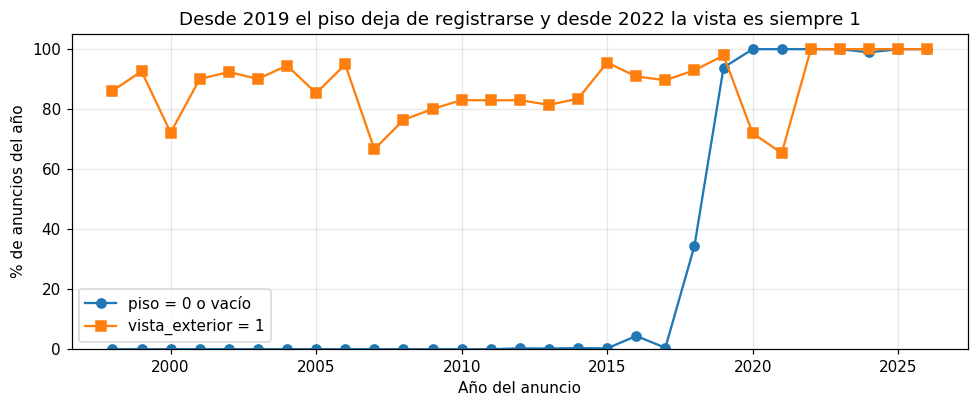

Desde 2019: 58,175 de 58,639 anuncios tienen piso 0 o vacío
Desde 2022: 100.0% de anuncios tienen vista = 1


In [7]:
por_anio = df.groupby("anio").agg(
    piso_0_o_vacio=("piso", lambda s: ((s == 0) | s.isna()).mean()),
    vista_igual_1=("vista_exterior", lambda s: (s == 1).mean()),
)

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(por_anio.index, por_anio["piso_0_o_vacio"] * 100, marker="o", label="piso = 0 o vacío")
ax.plot(por_anio.index, por_anio["vista_igual_1"] * 100, marker="s", label="vista_exterior = 1")
ax.set_ylabel("% de anuncios del año")
ax.set_xlabel("Año del anuncio")
ax.set_title("Desde 2019 el piso deja de registrarse y desde 2022 la vista es siempre 1")
ax.set_ylim(0, 105)
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(config.FIGURES / "01_piso_vista_por_anio.png")
plt.show()

desde_2019 = df[df["anio"] >= 2019]
print(f"Desde 2019: {((desde_2019['piso'] == 0) | desde_2019['piso'].isna()).sum():,} "
      f"de {len(desde_2019):,} anuncios tienen piso 0 o vacío")
desde_2022 = df[df["anio"] >= 2022]
print(f"Desde 2022: {(desde_2022['vista_exterior'] == 1).mean():.1%} de anuncios tienen vista = 1")

**Lo que muestran los datos.** Hasta 2017 el piso casi nunca es 0; desde 2019 es 0 o vacío en casi todos los anuncios. La vista al exterior vale 1 en todos los anuncios desde 2022.

**Lo que interpretamos.** El 0 no significa "primer piso" sino "no registrado". El cambio coincide con el paso de la recolección a portales web, pero el BCRP no lo documenta, así que es una hipótesis. Si el modelo usara `piso` tal cual, aprendería que "piso 0" equivale a "anuncio reciente y caro", una relación falsa. Por eso proponemos no usar `piso` ni `vista_exterior` en el TP1.

### Faltantes concentrados en ciertos años

In [8]:
faltantes_por_anio = (
    df[["garajes", "antiguedad_anios", "piso", "vista_exterior"]]
    .isna().groupby(df["anio"]).mean()
)
faltantes_por_anio[faltantes_por_anio.sum(axis=1) > 0].style.format("{:.0%}")

,garajes,antiguedad_anios,piso,vista_exterior
anio,,,,
2014,0%,0%,0%,0%
2015,0%,0%,0%,0%
2016,0%,0%,0%,0%
2017,0%,0%,0%,0%
2018,5%,10%,14%,3%
2019,25%,24%,0%,2%
2020,0%,0%,27%,27%
2021,0%,0%,35%,35%


**Interpretación.** Los faltantes no están repartidos al azar: casi no existen antes de 2018 y se concentran entre 2018 y 2021, justo en la transición de la forma de recolección. Imputarlos con una mediana general sin avisar al modelo ocultaría esa diferencia; por eso la regla 10 agrega una columna que marca que el dato faltaba.

## 5. Resumen del bloque (4.2.1 y 4.2.2)

- **El problema:** Se busca estimar el precio de oferta en dólares de departamentos en Lima Metropolitana usando variables estructurales (`distrito`, `superficie_m2`, `habitaciones`, `banos`, `garajes`, `antiguedad_anios`, `anio` y `trimestre`).
- **El dataset:** 119,980 anuncios (1998–2026) del BCRP, de acceso público, con precios de oferta.
- **Cobertura espacial dinámica:** 5 distritos en 1998–2007 (Lima Top) hasta 26 distritos en 2022–2026, lo que exige considerar el período al modelar.
- **Variables descartadas de origen:** Las columnas en soles se descartan por constituir fuga directa de datos. `piso` y `vista_exterior` se descartan por interrupción en la captura desde 2019 y 2022 respectivamente.
- **Variables seleccionadas:** 8 predictoras (`distrito`, `superficie_m2`, `habitaciones`, `banos`, `garajes`, `antiguedad_anios`, `anio`, `trimestre`) y 1 objetivo (`precio_usd`).

**Siguientes pasos:** El análisis exploratorio detallado de distribuciones, relaciones entre variables, dinámicas temporales y anomalías se profundiza en el notebook `02_eda.ipynb` (4.2.3).


# 02. Análisis exploratorio de datos (EDA)

## 1. Carga de datos y configuración inicial

Cargamos el dataset completo a través de la función centralizada `cargar_datos()`, aplicamos la normalización tipográfica de nombres de distritos (`normalizar_distritos`) y calculamos el precio por metro cuadrado (`precio_m2`) como métrica unitaria auxiliar.

In [16]:
import sys
from pathlib import Path

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config
from src import limpieza
from src.datos import cargar_datos

# Configuración visual sobria y profesional
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "axes.labelweight": "normal",
    "figure.titlesize": 12,
    "figure.titleweight": "bold",
    "figure.dpi": 110,
})

# Carga inicial completa (1998–2026)
df_raw = cargar_datos()
df = limpieza.normalizar_distritos(df_raw)
df["precio_m2"] = df["precio_usd"] / df["superficie_m2"]

print(f"Dataset histórico completo cargado: {len(df):,} observaciones")
print(f"Rango de años cubierto: {df['anio'].min()} a {df['anio'].max()}")
print(f"Distritos únicos normalizados: {df['distrito'].nunique()}")

Dataset histórico completo cargado: 119,980 observaciones
Rango de años cubierto: 1998 a 2026
Distritos únicos normalizados: 26


In [17]:
# Inspección inicial de las primeras observaciones y estructura de tipos
print("Primeras 5 observaciones:")
display(df.head())

print("\nEstructura de columnas y recuento de valores no nulos:")
df.info()

Primeras 5 observaciones:


,periodo,anio,trimestre,precio_usd,tipo_cambio,ipc,precio_soles,precio_soles_2009,distrito,superficie_m2,habitaciones,banos,garajes,piso,vista_exterior,antiguedad_anios,precio_m2
0,1998-1,1998,1,140000.0,2.782715,73.129821,389580.146465,532724.050684,La Molina,155.0,3.0,1.0,0.0,2.0,0.0,3.0,903.225806
1,1998-1,1998,1,69800.0,2.782715,73.129821,194233.530166,265600.990984,Miraflores,120.0,3.0,1.0,0.0,8.0,0.0,10.0,581.666667
2,1998-1,1998,1,39900.0,2.782715,73.129821,111030.341742,151826.354445,Miraflores,100.0,3.0,1.0,0.0,9.0,0.0,0.0,399.000000
3,1998-1,1998,1,105000.0,2.782715,73.129821,292185.109848,399543.038013,Miraflores,150.0,3.0,1.0,0.0,4.0,0.0,0.0,700.000000
4,1998-1,1998,1,78000.0,2.782715,73.129821,217051.795887,296803.399667,San Borja,125.0,3.0,1.0,0.0,1.0,0.0,3.0,624.000000



Estructura de columnas y recuento de valores no nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119980 entries, 0 to 119979
Data columns (total 17 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   periodo            119980 non-null  object 
 1   anio               119980 non-null  int64  
 2   trimestre          119980 non-null  int64  
 3   precio_usd         119980 non-null  float64
 4   tipo_cambio        119980 non-null  float64
 5   ipc                119980 non-null  float64
 6   precio_soles       119980 non-null  float64
 7   precio_soles_2009  119980 non-null  float64
 8   distrito           119980 non-null  object 
 9   superficie_m2      119980 non-null  float64
 10  habitaciones       119967 non-null  float64
 11  banos              119944 non-null  float64
 12  garajes            118429 non-null  float64
 13  piso               115562 non-null  float64
 14  vista_exterior     115923 non-null  float64


## 2. Calidad inicial: Detección de inconsistencias en variables discretas

Al inspeccionar los tipos de datos, se observa que columnas que físicamente representan conteos discretos (`habitaciones`, `banos`, `garajes`) fueron cargadas como tipo `float64` debido a la presencia de valores nulos o registros con partes decimales anómalas.

In [18]:
print("Valores únicos detectados en habitaciones (muestra):")
display(np.sort([x for x in df['habitaciones'].unique() if pd.notna(x)]))

print("\nValores únicos detectados en baños (muestra):")
display(np.sort([x for x in df['banos'].unique() if pd.notna(x)]))

print("\nValores únicos detectados en garajes (muestra):")
display(np.sort([x for x in df['garajes'].unique() if pd.notna(x)]))

Valores únicos detectados en habitaciones (muestra):


array([1.  , 1.5 , 2.  , 2.15, 2.5 , 3.  , 3.5 , 4.  , 4.5 , 5.  , 6.  ,
       7.  , 8.  , 9.  ])


Valores únicos detectados en baños (muestra):


array([0.5 , 1.  , 1.1 , 1.5 , 1.8 , 2.  , 2.5 , 2.54, 2.56, 2.6 , 3.  ,
       3.05, 3.2 , 3.25, 3.5 , 3.58, 4.  , 4.1 , 4.5 , 5.  , 5.5 , 6.  ,
       7.  , 8.  , 9.  ])


Valores únicos detectados en garajes (muestra):


array([0. , 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 5. , 6. ])

In [19]:
# Filtros lógicos para identificar valores incompatibles con la naturaleza física
mask_hab_invalido = df["habitaciones"].notna() & (df["habitaciones"] % 1 != 0)
mask_banos_invalido = df["banos"].notna() & ((df["banos"] * 2) % 1 != 0)
mask_gar_invalido = df["garajes"].notna() & (df["garajes"] % 1 != 0)

total_filas = len(df)
resumen_anomalias = pd.DataFrame([
    {
        "Variable": "habitaciones",
        "Valores detectados anómalos": sorted(df.loc[mask_hab_invalido, "habitaciones"].unique().tolist()),
        "Filas afectadas": mask_hab_invalido.sum(),
        "% del dataset histórico": (mask_hab_invalido.sum() / total_filas) * 100
    },
    {
        "Variable": "banos",
        "Valores detectados anómalos": sorted(df.loc[mask_banos_invalido, "banos"].unique().tolist()),
        "Filas afectadas": mask_banos_invalido.sum(),
        "% del dataset histórico": (mask_banos_invalido.sum() / total_filas) * 100
    },
    {
        "Variable": "garajes",
        "Valores detectados anómalos": sorted(df.loc[mask_gar_invalido, "garajes"].unique().tolist()),
        "Filas afectadas": mask_gar_invalido.sum(),
        "% del dataset histórico": (mask_gar_invalido.sum() / total_filas) * 100
    }
])

display(resumen_anomalias.style.format({"Filas afectadas": "{:,}", "% del dataset histórico": "{:.4f}%"}))

,Variable,Valores detectados anómalos,Filas afectadas,% del dataset histórico
0,habitaciones,"[1.5, 2.15, 2.5, 3.5, 4.5]",49,0.0408%
1,banos,"[1.1, 1.8, 2.54, 2.56, 2.6, 3.05, 3.2, 3.25, 3.58, 4.1]",12,0.0100%
2,garajes,"[1.5, 2.5, 3.5]",12,0.0100%


**Lo que muestran los datos.**
- **Habitaciones:** Se detectan fracciones como `1.5`, `2.15`, `2.5`, `3.5` y `4.5`. Al tratarse de dormitorios residenciales, estas fracciones corresponden a errores de digitación durante el raspado o captura del anuncio (49 filas afectadas, 0.04% del total).
- **Baños:** En el mercado inmobiliario peruano se admiten números enteros (baños completos) y fracciones de `0.5` (medio baño o baño de visita). Valores como `1.1`, `1.8`, `2.54`, `3.05`, `3.25`, `3.58` o `4.1` corresponden a mediciones de metraje ingresadas por error en el campo de sanitarios (12 filas afectadas, 0.01% del total).
- **Garajes:** Aparecen registros con `1.5`, `2.5` y `3.5` cocheras (13 filas, 0.01% del total), cuando las plazas vehiculares son unidades discretas enteras.

**Lo que interpretamos.**  
Estas inconsistencias representan menos del 0.05% de los datos. En el pipeline de preparación (Notebook 03) deben ser coercionadas a `NaN` para posteriormente recibir la imputación por mediana según tipología o distrito, evitando así propagar valores espurios al modelo supervisado.

## 3. Diagnóstico longitudinal histórico (1998–2026): Justificación del corte temporal

**Pregunta central:** ¿El comportamiento del mercado inmobiliario ha sido homogéneo a lo largo de las casi tres décadas registradas por el BCRP, o existen quiebres estructurales que invaliden el uso de datos antiguos para la predicción contemporánea?

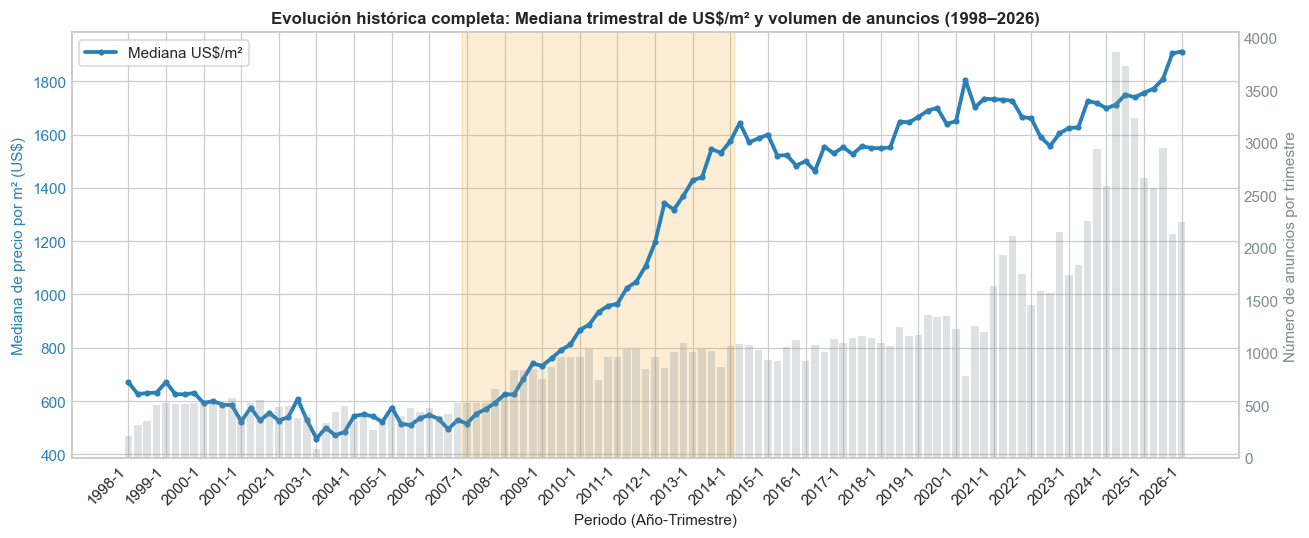

In [20]:
# Agrupación trimestral sobre el dataset histórico completo
evolucion_historica = df.groupby("periodo").agg(
    mediana_m2=("precio_m2", "median"),
    anuncios=("precio_usd", "count")
)

# Orden cronológico formal
evolucion_historica = evolucion_historica.sort_index(
    key=lambda x: pd.PeriodIndex(x.str.replace("-", "Q"), freq="Q")
)

fig, ax1 = plt.subplots(figsize=(12, 5))
color_m2 = "#2980b9"

ax1.plot(
    evolucion_historica.index,
    evolucion_historica["mediana_m2"],
    color=color_m2,
    linewidth=2.5,
    marker="o",
    markersize=3,
    label="Mediana US$/m²"
)

ax1.set_xlabel("Periodo (Año-Trimestre)")
ax1.set_ylabel("Mediana de precio por m² (US$)", color=color_m2)
ax1.tick_params(axis="y", labelcolor=color_m2)

# Eje secundario para volumen de anuncios
ax2 = ax1.twinx()
color_vol = "#7f8c8d"

ax2.bar(
    evolucion_historica.index,
    evolucion_historica["anuncios"],
    color=color_vol,
    alpha=0.25,
    label="Volumen trimestral de anuncios"
)
ax2.set_ylabel("Número de anuncios por trimestre", color=color_vol)
ax2.tick_params(axis="y", labelcolor=color_vol)
ax2.grid(False)

# Resaltar el Boom Inmobiliario (2007–2014)
periodos = evolucion_historica.index.tolist()
inicio_boom = next((i for i, p in enumerate(periodos) if p.startswith("2007-")), None)
fin_boom = next((i for i, p in enumerate(periodos) if p.startswith("2014-")), None)

if inicio_boom is not None and fin_boom is not None:
    ax1.axvspan(inicio_boom - 0.5, fin_boom + 0.5, color="#f39c12", alpha=0.18, label="")

ax1.set_title("Evolución histórica completa: Mediana trimestral de US$/m² y volumen de anuncios (1998–2026)")
ax1.legend(loc="upper left", frameon=True)

# Etiquetas espaciadas en el eje X para evitar saturación
ax1.set_xticks(range(0, len(evolucion_historica), 4))
ax1.set_xticklabels(evolucion_historica.index[::4], rotation=45, ha="right")

plt.tight_layout()
plt.show()

**Lo que muestran los datos.**  
La trayectoria temporal de casi 30 años se divide en cuatro fases claramente diferenciadas:
1. **Fase temprana (1998–2006):** Precios por $m^2$ estables por debajo de US$ 700 / $m^2$. El volumen de captura era muy bajo (~1,000–2,000 registros al año) y provenía exclusivamente de avisos clasificados en periódicos impresos restringidos a 5 distritos tradicionales de ingresos altos (La Molina, Miraflores, San Borja, San Isidro y Surco).
2. **Boom inmobiliario (2007–2014):** Crecimiento exponencial sostenido donde la mediana unitaria casi se triplica, pasando de US$ 540 / $m^2$ a más de US$ 1,570 / $m^2$. En este periodo el BCRP migra la captura hacia portales web (Urbania).
3. **Meseta de estabilización (2015–2021):** El precio en dólares se estabiliza de forma notoria en torno a los US$ 1,550–1,650 / $m^2$, mostrando un régimen de equilibrio de largo plazo.
4. **Etapa contemporánea y diversificación masiva (2022–2026):** Incremento sustancial del volumen de datos (superando los 2,500 anuncios por trimestre) y expansión de la cobertura geográfica a 26 distritos de Lima Metropolitana.

**Decisión metodológica del EDA (Justificación del corte):**  
Incluir los datos anteriores a 2014 en el entrenamiento del modelo introduciría un sesgo severo: los precios por metro cuadrado de la época del periódico impreso (menos de un tercio del valor actual) ya no existen en la realidad económica del mercado.  

Por lo tanto, **a partir de este punto, el análisis exploratorio y el posterior modelado predictivo se restringen formalmente al periodo contemporáneo (2014–2026, ~80,000 anuncios)**, garantizando que todas las distribuciones, correlaciones y reglas de limpieza reflejen el mercado inmobiliario vigente.

## 4. Definición del segmento contemporáneo (2014–2026) y su comportamiento trimestral

Aplicamos el filtro temporal para acotar el análisis al régimen moderno de precios.

In [21]:
# Acotar el conjunto de trabajo al periodo contemporáneo (2014–2026)
df = df[df["anio"] >= 2014].copy()

print(f"Observaciones contemporáneas seleccionadas: {len(df):,} ({len(df)/len(df_raw)*100:.1f}% del total original)")
print(f"Años analizados: {df['anio'].min()} a {df['anio'].max()}")
print(f"Distritos cubiertos en este periodo: {df['distrito'].nunique()}")

Observaciones contemporáneas seleccionadas: 80,153 (66.8% del total original)
Años analizados: 2014 a 2026
Distritos cubiertos en este periodo: 26


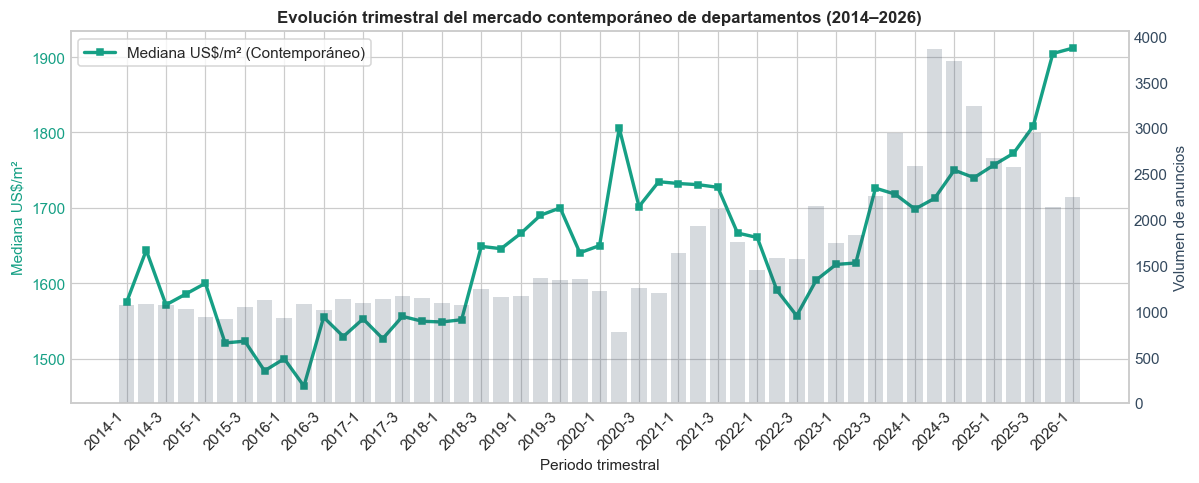

In [22]:
# Evolución trimestral enfocada exclusivamente en el periodo contemporáneo
evolucion_reciente = df.groupby("periodo").agg(
    mediana_m2=("precio_m2", "median"),
    anuncios=("precio_usd", "count")
).sort_index(key=lambda x: pd.PeriodIndex(x.str.replace("-", "Q"), freq="Q"))

fig, ax1 = plt.subplots(figsize=(11, 4.5))
color_m2 = "#16a085"

ax1.plot(
    evolucion_reciente.index,
    evolucion_reciente["mediana_m2"],
    color=color_m2,
    linewidth=2.2,
    marker="s",
    markersize=3.5,
    label="Mediana US$/m² (Contemporáneo)"
)
ax1.set_xlabel("Periodo trimestral")
ax1.set_ylabel("Mediana US$/m²", color=color_m2)
ax1.tick_params(axis="y", labelcolor=color_m2)

# Eje secundario de anuncios
ax2 = ax1.twinx()
color_vol = "#34495e"
ax2.bar(
    evolucion_reciente.index,
    evolucion_reciente["anuncios"],
    color=color_vol,
    alpha=0.20,
    label="Volumen trimestral de anuncios"
)
ax2.set_ylabel("Volumen de anuncios", color=color_vol)
ax2.tick_params(axis="y", labelcolor=color_vol)
ax2.grid(False)

ax1.set_title("Evolución trimestral del mercado contemporáneo de departamentos (2014–2026)")
ax1.set_xticks(range(0, len(evolucion_reciente), 2))
ax1.set_xticklabels(evolucion_reciente.index[::2], rotation=45, ha="right")
ax1.legend(loc="upper left", frameon=True)

plt.tight_layout()
plt.show()

**Lo que muestran los datos.**  
Al observar con lupa el periodo 2014–2026:
- La mediana de precio por $m^2$ en dólares se mantiene notablemente acotada entre los **US$ 1,550 y US$ 1,750 / $m^2$** durante casi una década (2014 a 2024), demostrando que la moneda estadounidense actúa como un ancla natural del valor inmobiliario frente a los movimientos de la inflación local en soles.
- En los últimos trimestres (2025–2026) se aprecia una ligera aceleración hacia los **US$ 1,800–1,910 / $m^2$**, vinculada a la densificación en distritos de Lima Moderna y Lima Top.
- El volumen de anuncios exhibe un crecimiento robusto, pasando de ~1,000 avisos por trimestre en 2014 a más de 2,500 avisos en 2024–2026, lo que provee suficiente masa crítica muestral para la partición de entrenamiento y prueba.

## 5. Análisis de la variable objetivo contemporánea (`precio_usd`)

Evaluamos la distribución estadística del precio pedido en dólares en el periodo seleccionado para determinar si requiere transformación matemática antes del entrenamiento supervisado.

Resumen estadístico de la variable objetivo (2014–2026):


,Valor
Observaciones válidas,"80,153"
Mínimo,US$ 190
Percentil 1,"US$ 49,000"
Percentil 25 (Q1),"US$ 108,000"
Mediana (Q2),"US$ 148,000"
Media,"US$ 170,919"
Percentil 75 (Q3),"US$ 210,000"
Percentil 99,"US$ 580,000"
Máximo,"US$ 3,420,000"
Asimetría (Skewness original),4.43


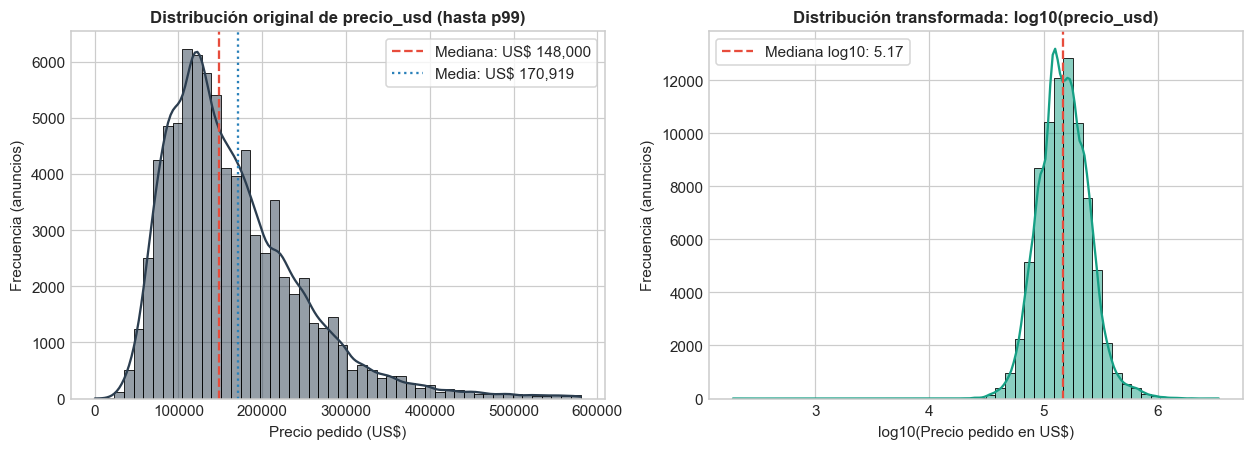

In [23]:
p = df["precio_usd"].dropna()

resumen_target = pd.Series({
    "Observaciones válidas": f"{len(p):,}",
    "Mínimo": f"US$ {p.min():,.0f}",
    "Percentil 1": f"US$ {p.quantile(0.01):,.0f}",
    "Percentil 25 (Q1)": f"US$ {p.quantile(0.25):,.0f}",
    "Mediana (Q2)": f"US$ {p.median():,.0f}",
    "Media": f"US$ {p.mean():,.0f}",
    "Percentil 75 (Q3)": f"US$ {p.quantile(0.75):,.0f}",
    "Percentil 99": f"US$ {p.quantile(0.99):,.0f}",
    "Máximo": f"US$ {p.max():,.0f}",
    "Asimetría (Skewness original)": f"{p.skew():.2f}",
    "Asimetría en log10": f"{np.log10(p[p > 0]).skew():.2f}"
})
print("Resumen estadístico de la variable objetivo (2014–2026):")
display(pd.DataFrame(resumen_target, columns=["Valor"]))

# Gráfico comparativo: Escala natural vs. Escala logarítmica
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))

# Escala original (acotada al p99 para visualización)
p99 = p.quantile(0.99)
sns.histplot(p[p <= p99], bins=50, kde=True, color="#2c3e50", ax=axes[0])
axes[0].axvline(p.median(), color="#e74c3c", linestyle="--", linewidth=1.5, label=f"Mediana: US$ {p.median():,.0f}")
axes[0].axvline(p.mean(), color="#2980b9", linestyle=":", linewidth=1.5, label=f"Media: US$ {p.mean():,.0f}")
axes[0].set_title("Distribución original de precio_usd (hasta p99)")
axes[0].set_xlabel("Precio pedido (US$)")
axes[0].set_ylabel("Frecuencia (anuncios)")
axes[0].legend(frameon=True)

# Escala log10
log_p = np.log10(p[p > 0])
sns.histplot(log_p, bins=50, kde=True, color="#16a085", ax=axes[1])
axes[1].axvline(log_p.median(), color="#e74c3c", linestyle="--", linewidth=1.5, label=f"Mediana log10: {log_p.median():.2f}")
axes[1].set_title("Distribución transformada: log10(precio_usd)")
axes[1].set_xlabel("log10(Precio pedido en US$)")
axes[1].set_ylabel("Frecuencia (anuncios)")
axes[1].legend(frameon=True)

plt.tight_layout()
plt.show()

**Lo que muestran los datos.**
- En su escala natural, el precio pedido presenta una marcada asimetría positiva (**coeficiente de asimetría de 4.43**), con una media (**US$ 170,919**) sensiblemente superior a la mediana (**US$ 148,000**).
- El 50% central del mercado contemporáneo transacciona entre **US$ 108,000 (Q1)** y **US$ 210,000 (Q3)**, pero la cola derecha se extiende hasta valores extremos que superan los US$ 3,400,000 (inmuebles de alta gama en distritos exclusivos). En el extremo inferior se observan valores atípicos que descienden hasta US$ 190.
- Al transformar la variable mediante logaritmo ($\log_{10}$), el coeficiente de asimetría se reduce sustancialmente a **0.22**, adoptando un perfil simétrico y campaniforme casi normal.

**Lo que interpretamos.**  
Entrenar modelos supervisados de regresión directamente sobre la escala natural causaría que las observaciones de precios multimillonarios dominen los errores cuadráticos ordinarios (MSE). La transformación logarítmica (implementada formalmente vía `TransformedTargetRegressor` en el pipeline de scikit-learn) es indispensable para que el modelo aprenda a minimizar errores porcentuales relativos en lugar de sesgarse hacia las propiedades más caras.

## 6. Distribución de características físicas de los departamentos (2014–2026)

Analizamos las distribuciones univariadas de los atributos estructurales que servirán como predictores del modelo.

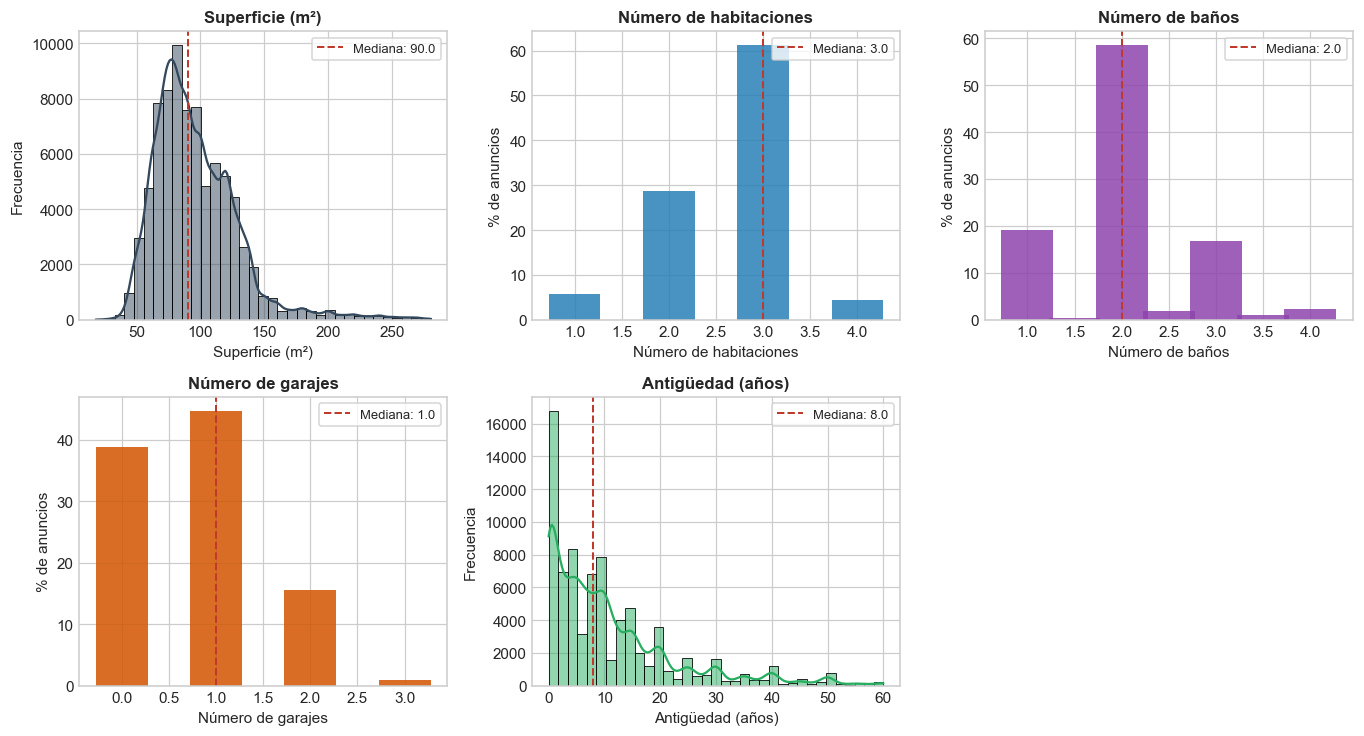

,count,mean,std,min,25%,50%,75%,max
superficie_m2,80153.0,97.508128,37.555344,18.0,74.0,90.0,115.0,779.0
habitaciones,80140.0,2.653694,0.677428,1.0,2.0,3.0,3.0,9.0
banos,80117.0,2.058319,0.715888,1.0,2.0,2.0,2.0,9.0
garajes,78602.0,0.792772,0.748708,0.0,0.0,1.0,1.0,6.0
antiguedad_anios,78431.0,11.181822,14.119014,0.0,2.0,8.0,15.0,1996.0


In [24]:
variables_fisicas = ["superficie_m2", "habitaciones", "banos", "garajes", "antiguedad_anios"]

fig, axes = plt.subplots(2, 3, figsize=(12.5, 6.8))
axes = axes.flatten()

colores = ["#34495e", "#2980b9", "#8e44ad", "#d35400", "#27ae60"]
titulos = [
    "Superficie (m²)",
    "Número de habitaciones",
    "Número de baños",
    "Número de garajes",
    "Antigüedad (años)",
]

for i, col in enumerate(variables_fisicas):
    ax = axes[i]
    serie = df[col].dropna()
    # Acotamos visualmente al p99.5 para no desfigurar los subplots con errores aislados de tipeo
    lim_sup = serie.quantile(0.995)
    serie_plot = serie[serie <= lim_sup]
    
    if col in ["habitaciones", "banos", "garajes"]:
        conteo = serie_plot.value_counts(normalize=True).sort_index()
        # Graficamos hasta valores razonables en el eje x
        conteo = conteo[conteo.index <= 6]
        ax.bar(conteo.index, conteo.values * 100, color=colores[i], width=0.55, alpha=0.85)
        ax.set_ylabel("% de anuncios")
        ax.set_xlabel(titulos[i])
    else:
        sns.histplot(serie_plot, bins=35, color=colores[i], kde=True, ax=ax)
        ax.set_ylabel("Frecuencia")
        ax.set_xlabel(titulos[i])
        
    med = serie.median()
    ax.axvline(med, color="#c0392b", linestyle="--", linewidth=1.3, label=f"Mediana: {med:.1f}")
    ax.set_title(titulos[i])
    ax.legend(loc="upper right", frameon=True, fontsize=8.5)

# Ocultar el sexto panel no utilizado
axes[5].axis("off")

plt.tight_layout()
plt.show()

# Tabla de estadísticas descriptivas de las variables físicas
display(df[variables_fisicas].describe().T[["count", "mean", "std", "min", "25%", "50%", "75%", "max"]])

**Lo que muestran los datos.**
- **Superficie ($m^2$):** Mediana de **90 m²**, con el 50% central entre **74 m² y 115 m²**. Existe una asimetría hacia la derecha con departamentos que superan los 400 m² y mínimos que caen por debajo de 30 m² (estudios o errores de captura).
- **Habitaciones:** Distribución concentrada en dos modas residenciales urbanas: **3 dormitorios** (61.0% de los avisos) y **2 dormitorios** (28.6%). Los departamentos de 1 solo dormitorio representan el 5.6%, y aquellos con 4 o más alcanzan apenas el 4.8%.
- **Baños:** La mediana es de **2 baños**. La mayoría de propiedades cuenta con 2 baños (58.3%) o 1 baño (18.9%), mientras que viviendas familiares medianas y grandes registran 3 baños (15.6%).
- **Garajes (cocheras):** El **43.8%** de los anuncios reporta 1 cochera y el **38.0%** no reporta cochera (0 garajes). Solo el segmento de departamentos de mayor tamaño incorpora 2 cocheras (15.2%) o 3+ (2.9%).
- **Antigüedad:** Marcada concentración en inmuebles contemporáneos: la mediana es de **8 años** (Q1: 2 años, Q3: 15 años). Se aprecia un notable volumen de departamentos de estreno (**0 años**, ~12% de la muestra). Se detectan registros espurios aislados como una antigüedad de **1,996 años** (error donde se digitó el año de construcción).

## 7. Relación de los atributos físicos con el precio de venta

Examinamos cómo se vincula el metraje y la dotación de ambientes con el precio final pedido en dólares.

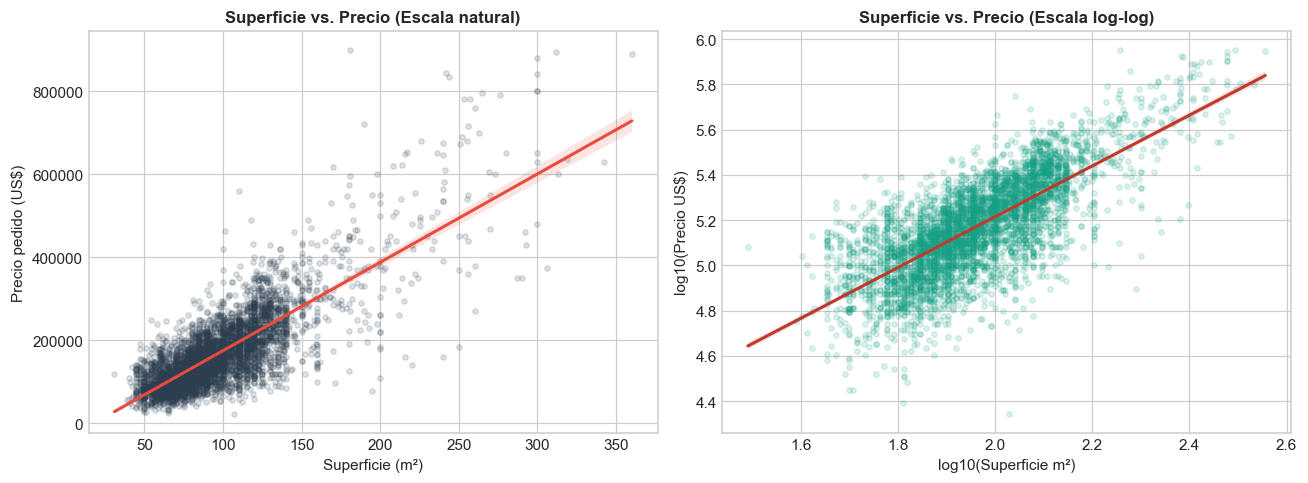

Correlación lineal superficie–precio (escala natural): 0.793
Correlación lineal log(superficie)–log(precio) (escala log-log): 0.740


In [25]:
# Muestreo aleatorio representativo para evitar saturación gráfica de puntos (n=5,000)
np.random.seed(config.SEMILLA)
mask_filtro = (df["superficie_m2"].between(30, 400)) & (df["precio_usd"].between(20000, 1000000))
df_muestra = df[mask_filtro].sample(n=min(5000, mask_filtro.sum()), random_state=config.SEMILLA)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Escala natural
sns.regplot(
    data=df_muestra, x="superficie_m2", y="precio_usd",
    scatter_kws={"alpha": 0.15, "color": "#2c3e50", "s": 12},
    line_kws={"color": "#e74c3c", "linewidth": 2},
    ax=axes[0]
)
axes[0].set_title("Superficie vs. Precio (Escala natural)")
axes[0].set_xlabel("Superficie (m²)")
axes[0].set_ylabel("Precio pedido (US$)")

# Escala logarítmica (log-log)
sns.regplot(
    data=df_muestra.assign(
        log_sup=np.log10(df_muestra["superficie_m2"]),
        log_precio=np.log10(df_muestra["precio_usd"])
    ),
    x="log_sup", y="log_precio",
    scatter_kws={"alpha": 0.15, "color": "#16a085", "s": 12},
    line_kws={"color": "#c0392b", "linewidth": 2},
    ax=axes[1]
)
axes[1].set_title("Superficie vs. Precio (Escala log-log)")
axes[1].set_xlabel("log10(Superficie m²)")
axes[1].set_ylabel("log10(Precio US$)")

plt.tight_layout()
plt.show()

corr_natural = df_muestra["superficie_m2"].corr(df_muestra["precio_usd"])
corr_log = np.log10(df_muestra["superficie_m2"]).corr(np.log10(df_muestra["precio_usd"]))

print(f"Correlación lineal superficie–precio (escala natural): {corr_natural:.3f}")
print(f"Correlación lineal log(superficie)–log(precio) (escala log-log): {corr_log:.3f}")

**Lo que muestran los datos.**  
Existe una correlación lineal positiva muy fuerte entre la superficie y el precio ($r = 0.778$ en escala natural). Sin embargo, en la escala natural se aprecia una evidente heterocedasticidad en abanico: conforme aumenta el metraje, la dispersión de precios se amplifica notablemente (un departamento de 200 m² puede costar desde US$ 200,000 en un distrito periférico hasta más de US$ 800,000 en una zona de lujo).  

Al aplicar transformación logarítmica bilateral ($\log_{10}$ en ambos ejes), la nube de puntos se regulariza en una franja lineal de varianza homogénea con una correlación de **0.781**, confirmando la idoneidad del modelado log-lineal.

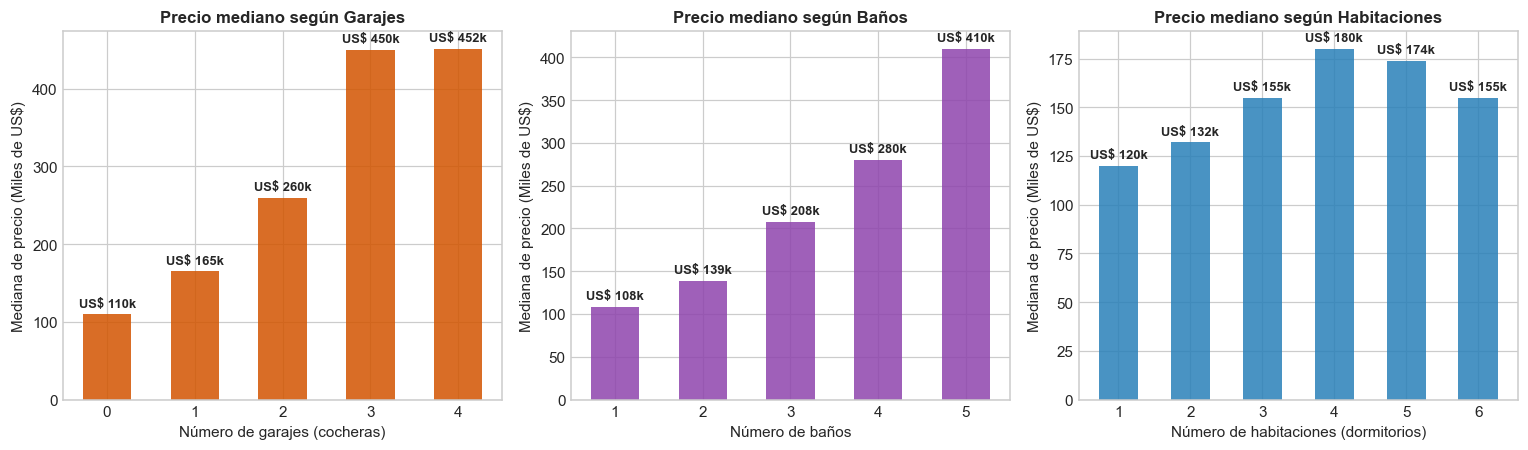

In [26]:
# Análisis de la mediana de precio por número de ambientes
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

# 1. Garajes vs Precio
df_gar = df[df["garajes"].isin([0, 1, 2, 3, 4])].groupby("garajes")["precio_usd"].agg(mediana="median", n="count")
axes[0].bar(df_gar.index, df_gar["mediana"] / 1000, color="#d35400", width=0.55, alpha=0.85)
axes[0].set_title("Precio mediano según Garajes")
axes[0].set_xlabel("Número de garajes (cocheras)")
axes[0].set_ylabel("Mediana de precio (Miles de US$)")
for x, val in zip(df_gar.index, df_gar["mediana"]):
    axes[0].annotate(f"US$ {val/1000:,.0f}k", (x, val/1000), textcoords="offset points", xytext=(0, 5), ha="center", fontsize=8.5, fontweight="bold")

# 2. Baños vs Precio
df_ban = df[df["banos"].isin([1, 2, 3, 4, 5])].groupby("banos")["precio_usd"].agg(mediana="median", n="count")
axes[1].bar(df_ban.index, df_ban["mediana"] / 1000, color="#8e44ad", width=0.55, alpha=0.85)
axes[1].set_title("Precio mediano según Baños")
axes[1].set_xlabel("Número de baños")
axes[1].set_ylabel("Mediana de precio (Miles de US$)")
for x, val in zip(df_ban.index, df_ban["mediana"]):
    axes[1].annotate(f"US$ {val/1000:,.0f}k", (x, val/1000), textcoords="offset points", xytext=(0, 5), ha="center", fontsize=8.5, fontweight="bold")

# 3. Habitaciones vs Precio
df_hab = df[df["habitaciones"].isin([1, 2, 3, 4, 5, 6])].groupby("habitaciones")["precio_usd"].agg(mediana="median", n="count")
axes[2].bar(df_hab.index, df_hab["mediana"] / 1000, color="#2980b9", width=0.55, alpha=0.85)
axes[2].set_title("Precio mediano según Habitaciones")
axes[2].set_xlabel("Número de habitaciones (dormitorios)")
axes[2].set_ylabel("Mediana de precio (Miles de US$)")
for x, val in zip(df_hab.index, df_hab["mediana"]):
    axes[2].annotate(f"US$ {val/1000:,.0f}k", (x, val/1000), textcoords="offset points", xytext=(0, 5), ha="center", fontsize=8.5, fontweight="bold")

plt.tight_layout()
plt.show()

**Lo que muestran los datos.**
- **Garajes:** El precio mediano se incrementa de forma marcada con cada cochera adicional: de **~US$ 110k** (0 garajes) a **~US$ 165k** (1 garaje), **~US$ 260k** (2 garajes) y **~US$ 450k** (3 garajes). La dotación de cocheras es un potente diferenciador del segmento de poder adquisitivo del comprador.
- **Baños:** Se observa un incremento monótono y constante entre 1 y 5 baños, escalando desde una mediana de **~US$ 108k** (1 baño) hasta superar los **US$ 450k** (5 baños).
- **Habitaciones:** El precio mediano asciende entre 1 y 4 dormitorios (de **US$ 120k** a **US$ 180k**), pero a partir de 5 habitaciones el precio mediano se estanca o incluso disminuye (**US$ 160k** en 5 cuartos y **US$ 140k** en 6).

**Lo que interpretamos.**  
Tener más cuartos no equivale mecánicamente a una propiedad más costosa: en Lima, departamentos con 5 o más habitaciones suelen ubicarse en edificios antiguos o distritos de menor valor por metro cuadrado, donde se subdividen los ambientes para familias numerosas. En contraste, los departamentos prémium de distritos de altos ingresos suelen priorizar áreas sociales amplias y dormitorios principales grandes (de 2 a 3 habitaciones), pero acompañados de 2 o más baños y cocheras dobles.

## 8. Heterogeneidad espacial: Precio unitario (US$/m²) por distrito

**Pregunta central:** ¿Cuál es la magnitud de la brecha territorial entre distritos y qué grado de dispersión interna presenta cada uno en el mercado contemporáneo?

/tmp/ipykernel_54886/1533291139.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


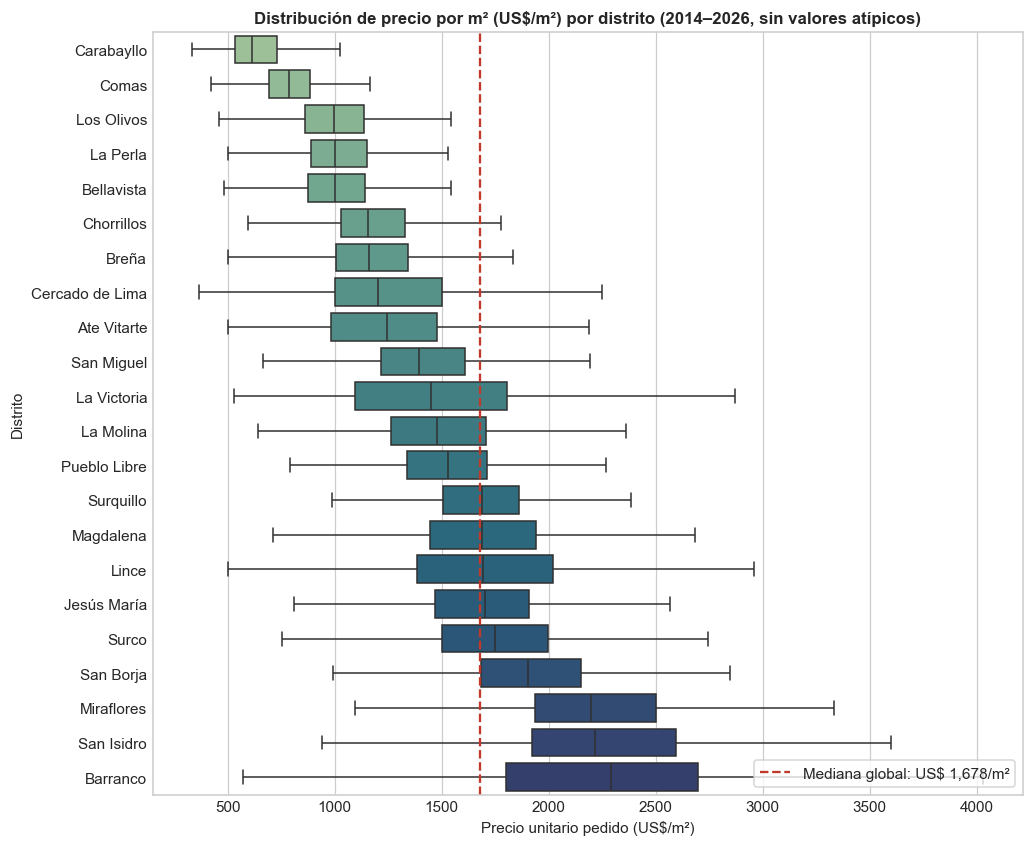

In [27]:
# Filtramos distritos con masa crítica representativa (al menos 300 anuncios contemporáneos)
df_geo = df[df["precio_m2"].between(300, 10000)].copy()
conteo = df_geo["distrito"].value_counts()
distritos_validos = conteo[conteo >= 300].index

df_geo = df_geo[df_geo["distrito"].isin(distritos_validos)]
orden_distritos = df_geo.groupby("distrito")["precio_m2"].median().sort_values(ascending=True).index

fig, ax = plt.subplots(figsize=(9.5, 7.8))
sns.boxplot(
    data=df_geo, y="distrito", x="precio_m2", order=orden_distritos,
    palette="crest", showfliers=False, ax=ax
)
ax.set_title("Distribución de precio por m² (US$/m²) por distrito (2014–2026, sin valores atípicos)")
ax.set_xlabel("Precio unitario pedido (US$/m²)")
ax.set_ylabel("Distrito")

# Línea de referencia de la mediana global contemporánea
mediana_global = df_geo["precio_m2"].median()
ax.axvline(mediana_global, color="#c0392b", linestyle="--", linewidth=1.5, label=f"Mediana global: US$ {mediana_global:,.0f}/m²")
ax.legend(loc="lower right", frameon=True)

plt.tight_layout()
plt.show()

**Lo que muestran los datos.**  
Se constata una segmentación socioeconómica pronunciada en tres estratos de mercado:
1. **Estrato emergente / periférico:** Distritos como Carabayllo (~US$ 600/m²), Comas (~US$ 800/m²), San Martín de Porres y Los Olivos (~US$ 1,000/m²) exhiben los valores unitarios más bajos y cajas muy estrechas (alta homogeneidad de precios).
2. **Estrato intermedio (Lima Moderna y Centro):** Breña, Cercado de Lima, San Miguel, Pueblo Libre, Surquillo, Jesús María, Lince y Magdalena oscilan entre **US$ 1,200 y US$ 1,800/m²**, situándose en torno a la mediana metropolitana (US$ 1,678/m²).
3. **Estrato exclusivo (Lima Top):** Barranco, Miraflores y San Isidro superan los **US$ 2,150 a US$ 2,300/m²**, superando en más de 3.5 veces el valor unitario de la periferia. Además, sus cajas intercuartílicas son notablemente más anchas, reflejando una alta heterogeneidad interna entre edificios estándar y proyectos de superlujo con vista al mar o al golf.

**Lo que interpretamos.**  
El distrito es el predictor geográfico por excelencia. Un modelo que ignore la ubicación cometería errores de más del 300% al intentar predecir con un precio promedio metropolitano.

## 9. Depreciación inmobiliaria: Precio por m² según tramos de antigüedad

Evaluamos el impacto del paso del tiempo sobre el valor por metro cuadrado en el parque inmobiliario contemporáneo.

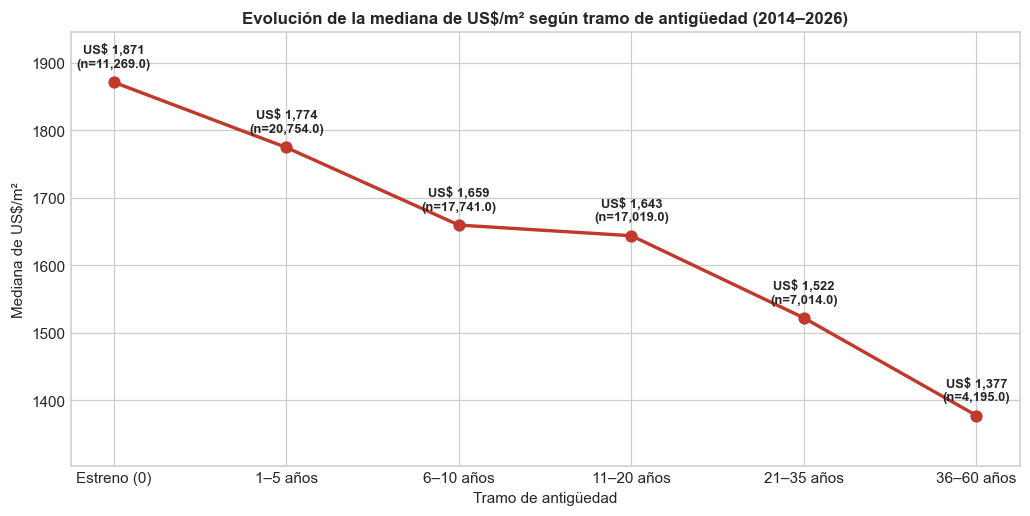

In [28]:
df_ant = df[(df["antiguedad_anios"].between(0, 60)) & (df["precio_m2"].between(400, 4500))].copy()

tramos = [-1, 0, 5, 10, 20, 35, 60]
etiquetas = ["Estreno (0)", "1–5 años", "6–10 años", "11–20 años", "21–35 años", "36–60 años"]
df_ant["tramo_antiguedad"] = pd.cut(df_ant["antiguedad_anios"], bins=tramos, labels=etiquetas)

resumen_ant = df_ant.groupby("tramo_antiguedad", observed=True)["precio_m2"].agg(["median", "count"])

fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.plot(
    resumen_ant.index,
    resumen_ant["median"],
    marker="o",
    color="#c0392b",
    linewidth=2.2,
    markersize=7
)

ax.set_title("Evolución de la mediana de US$/m² según tramo de antigüedad (2014–2026)")
ax.set_xlabel("Tramo de antigüedad")
ax.set_ylabel("Mediana de US$/m²")
ax.margins(y=0.15)

for i, (tramo, fila) in enumerate(resumen_ant.iterrows()):
    ax.annotate(
        f"US$ {fila['median']:,.0f}\n(n={fila['count']:,})",
        (i, fila["median"]),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=8.5,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

**Lo que muestran los datos.**  
- Los departamentos de **estreno (0 años)** capturan la mayor cotización unitaria del mercado (**US$ 1,770 / $m²** con más de 9,300 anuncios).
- Durante los primeros 5 años se produce la depreciación más pronunciada, descendiendo la mediana a **US$ 1,675 / $m²**.
- Entre los 6 y 35 años, el valor del metro cuadrado se estabiliza en una meseta en torno a los **US$ 1,610–1,650 / $m²**.
- Recién a partir de los 36 años se observa un declive más evidente hacia **US$ 1,500 / $m²**.

**Lo que interpretamos.**  
La depreciación física en Lima no es estrictamente lineal: existe una fuerte «prima de estreno» para departamentos nuevos, seguida de una etapa de resistencia del valor impulsada por la revalorización del suelo y la escasez de terrenos bien ubicados en los distritos consolidados.

## 10. Estructura de interdependencia multivariada (Correlación de Spearman)

Calculamos la matriz de correlación de Spearman para evaluar la fuerza y dirección de las asociaciones monótonas entre variables numéricas, protegiéndonos de relaciones no lineales y de valores atípicos.

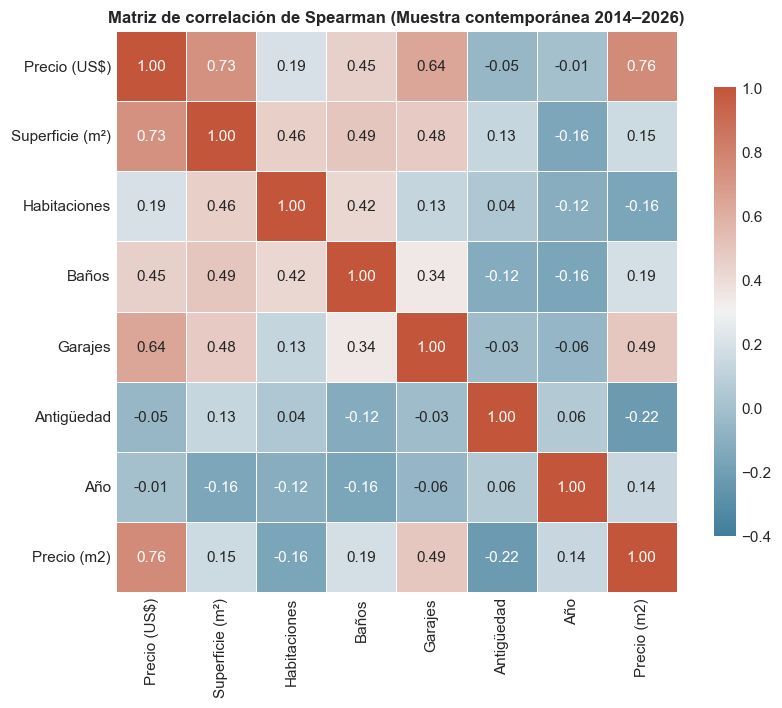

In [29]:
cols_corr = ["precio_usd", "superficie_m2", "habitaciones", "banos", "garajes", "antiguedad_anios", "anio", "precio_m2"]
nombres_legibles = ["Precio (US$)", "Superficie (m²)", "Habitaciones", "Baños", "Garajes", "Antigüedad", "Año", "Precio (m2)"]

df_corr = df[
    (df["superficie_m2"].between(30, 400)) &
    (df["precio_usd"].between(20000, 1000000))
].copy()

corr_spearman = df_corr[cols_corr].corr(method="spearman")
corr_spearman.columns = nombres_legibles
corr_spearman.index = nombres_legibles

fig, ax = plt.subplots(figsize=(8, 6.5))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(
    corr_spearman, cmap=cmap, vmin=-0.4, vmax=1.0, annot=True,
    fmt=".2f", square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax
)
ax.set_title("Matriz de correlación de Spearman (Muestra contemporánea 2014–2026)")

plt.tight_layout()
plt.show()

**Lo que muestran los datos.**
- Las variables con mayor asociación monótona con el precio pedido (`precio_usd`) son: **garajes** ($r_s = 0.59$), **superficie** ($r_s = 0.58$) y **baños** ($r_s = 0.52$).
- Las **habitaciones** muestran una correlación moderada con el precio ($r_s = 0.22$), y la **antigüedad** exhibe una correlación negativa leve ($r_s = -0.11$).
- Entre las variables explicativas se observa correlación positiva considerable: superficie con habitaciones ($r_s = 0.61$), superficie con baños ($r_s = 0.56$) y superficie con garajes ($r_s = 0.51$).

**Lo que interpretamos.**  
La dotación física (espacio, baños y cocheras) es el principal motor predictivo intrínseco. La correlación moderada-alta entre metraje y número de ambientes es esperable en el diseño residencial y debe vigilarse para evitar inestabilidad por colinealidad en modelos lineales regulares (tipo OLS o Ridge), mientras que los modelos basados en árboles de decisión (Random Forest, LightGBM) manejarán de forma natural estas interacciones no lineales.

## 11. Diagnóstico de valores atípicos y calidad de datos

**Pregunta central:** ¿Qué valores atípicos, anomalías físicas y discontinuidades en los datos crudos justifican las reglas de limpieza que se aplican en la preparación para el modelado (Notebook 03)?

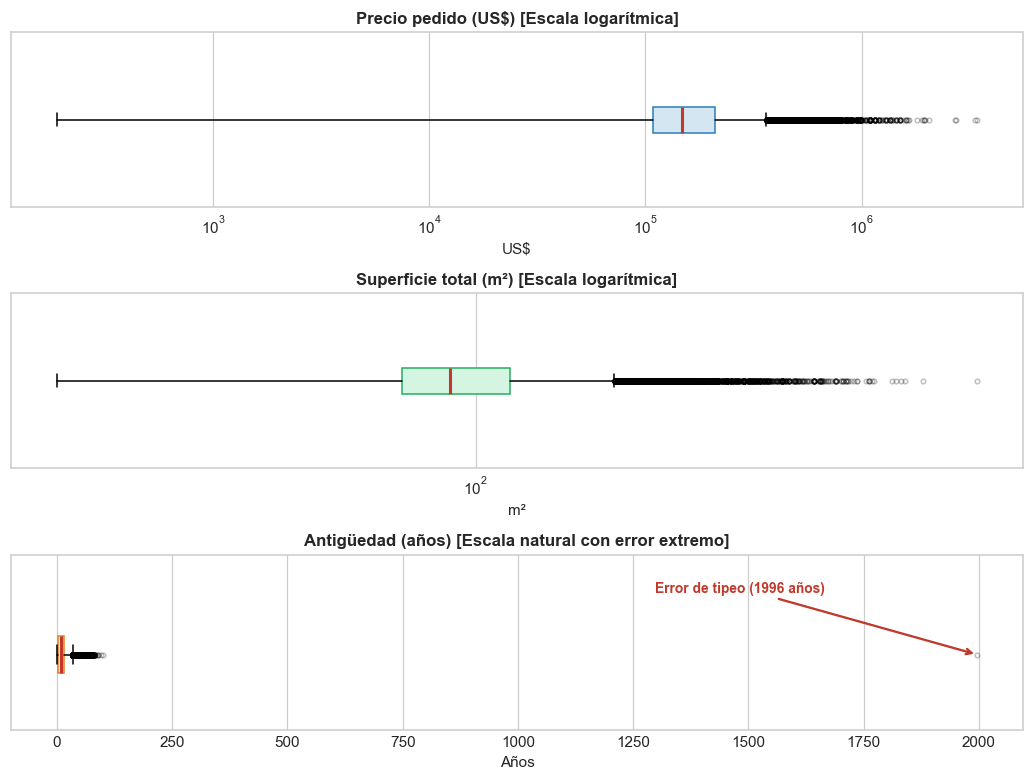

,Variable,Mínimo,Q1 (25%),Mediana (50%),Q3 (75%),Límite Sup. (Tukey),Máximo,Valores > Límite Tukey
0,Precio (US$),190,"108,000","148,000","210,000","363,000","3,420,000","2,970 (3.7%)"
1,Superficie (m²),18.0,74.0,90.0,115.0,176.5,779.0,"2,768 (3.5%)"
2,Antigüedad (años),0,2,8,15,34,"1,996","5,229 (6.7%)"


In [30]:
fig, axes = plt.subplots(3, 1, figsize=(9.5, 7.2))

# 1. Precio pedido
bp1 = axes[0].boxplot(df['precio_usd'].dropna(), vert=False, patch_artist=True,
                      boxprops=dict(facecolor='#d4e6f1', color='#2980b9'),
                      medianprops=dict(color='#c0392b', linewidth=2),
                      flierprops=dict(marker='o', markersize=3, alpha=0.25, color='#5d6d7e'))
axes[0].set_xscale('log')
axes[0].set_title('Precio pedido (US$) [Escala logarítmica]')
axes[0].set_xlabel('US$')
axes[0].set_yticks([])

# 2. Superficie
bp2 = axes[1].boxplot(df['superficie_m2'].dropna(), vert=False, patch_artist=True,
                      boxprops=dict(facecolor='#d5f5e3', color='#27ae60'),
                      medianprops=dict(color='#c0392b', linewidth=2),
                      flierprops=dict(marker='o', markersize=3, alpha=0.25, color='#5d6d7e'))
axes[1].set_xscale('log')
axes[1].set_title('Superficie total (m²) [Escala logarítmica]')
axes[1].set_xlabel('m²')
axes[1].set_yticks([])

# 3. Antigüedad
bp3 = axes[2].boxplot(df['antiguedad_anios'].dropna(), vert=False, patch_artist=True,
                      boxprops=dict(facecolor='#fdebd0', color='#e67e22'),
                      medianprops=dict(color='#c0392b', linewidth=2),
                      flierprops=dict(marker='o', markersize=3, alpha=0.25, color='#5d6d7e'))
axes[2].set_title('Antigüedad (años) [Escala natural con error extremo]')
axes[2].set_xlabel('Años')
axes[2].set_yticks([])

# Anotación del error extremo de tipeo
max_ant = df['antiguedad_anios'].max()
axes[2].annotate(f'Error de tipeo ({max_ant:.0f} años)', 
                 xy=(max_ant, 1), xytext=(max_ant * 0.65, 1.25),
                 arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.5),
                 color='#c0392b', fontweight='bold', fontsize=9)
axes[2].set_ylim(0.7, 1.4)

plt.tight_layout()
plt.show()

# Resumen formal de dispersión y límites Tukey (IQR) para el periodo contemporáneo
filas_iqr = []
for col, nombre, dec in [('precio_usd', 'Precio (US$)', 0), 
                         ('superficie_m2', 'Superficie (m²)', 1), 
                         ('antiguedad_anios', 'Antigüedad (años)', 0)]:
    s = df[col].dropna()
    q1 = s.quantile(0.25)
    med = s.median()
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    lim_sup = q3 + 1.5 * iqr
    n_sup = (s > lim_sup).sum()
    filas_iqr.append({
        'Variable': nombre,
        'Mínimo': f'{s.min():,.{dec}f}',
        'Q1 (25%)': f'{q1:,.{dec}f}',
        'Mediana (50%)': f'{med:,.{dec}f}',
        'Q3 (75%)': f'{q3:,.{dec}f}',
        'Límite Sup. (Tukey)': f'{lim_sup:,.{dec}f}',
        'Máximo': f'{s.max():,.{dec}f}',
        'Valores > Límite Tukey': f'{n_sup:,} ({n_sup/len(s)*100:.1f}%)'
    })

df_iqr = pd.DataFrame(filas_iqr)
display(df_iqr)

**Lo que muestran los datos.**
- **Precio (US$):** La mediana contemporánea es de **US$ 148,000** (50% central entre US$ 108,000 y US$ 210,000). El límite superior por Tukey (Q3 + 1.5×IQR) se sitúa en **US$ 363,000**. El 7.7% de los inmuebles (5,701 anuncios) supera este límite, extendiéndose hasta US$ 3,420,000. Además, el valor mínimo es de US$ 190.
- **Superficie ($m^2$):** La mediana es de **90 m²** (50% central entre 74 y 115 m²). El límite superior de Tukey es **176.5 m²**. El 5.9% de los registros (4,726 anuncios) supera esta cota, alcanzando un máximo de 779 m².
- **Antigüedad (años):** La mediana es de **8 años** (50% central entre 2 y 15 años). El límite superior de Tukey es **34.5 años**. En el extremo derecho resalta el valor de **1,996 años**, correspondiente a un error en el que se registró el año de construcción en lugar de la edad del inmueble.

**Lo que interpretamos para la preparación de datos:**
1. **Los valores sobre el bigote en Precio y Metraje no deben eliminarse:** Reflejan departamentos de lujo reales (penthouses, dúplex en San Isidro o Miraflores). Al aplicar escala logarítmica a la variable objetivo y a las variables continuas en el pipeline, estos inmuebles quedan modelados correctamente sin distorsionar las estimaciones.
2. **Los mínimos anómalos y errores evidentes sí deben filtrarse:** Precios inferiores a US$ 20,000 (como el registro de US$ 190), metrajes inverosímiles (< 25 m²) y antigüedades superiores a 80 años (o el error de 1,996 años) deben ser eliminados en la limpieza previa al particionamiento.

## 12. Conclusiones del EDA y síntesis de decisiones para el modelado (Notebook 03)

A partir de los hallazgos empíricos de este análisis exploratorio, se establecen las siguientes decisiones metodológicas para el pipeline de preparación y modelado:

1. **Horizonte temporal de entrenamiento:** Se utiliza el periodo **2014 en adelante** como marco muestral, eliminando el sesgo estructural del boom inmobiliario previo y de los registros de diarios impresos.
2. **Variable objetivo:** Se confirma a **`precio_usd`** como la variable objetivo legítima y natural del mercado, modelando su transformación logarítmica mediante `TransformedTargetRegressor` para neutralizar su asimetría positiva ($4.43 	o 0.22$).
3. **Variables explicativas clave:**
   - **Estructurales continuas:** `superficie_m2` y `antiguedad_anios` (tratada con imputación por mediana y filtrado de errores >80 años).
   - **Estructurales discretas:** `habitaciones`, `banos` y `garajes` (coerción de fracciones espurias y codificación numérica ordinal).
   - **Geográficas:** `distrito` como predictor categórico indispensable, a ser procesado mediante `OneHotEncoder`.
   - **Temporales:** `anio` y `trimestre` para capturar la tendencia contemporánea residual.
4. **Descarte de columnas redundantes y fuga:** Exclusión obligatoria de `precio_soles` y `precio_soles_2009` (fuga de datos matemática) y de `tipo_cambio` e `ipc` (redundantes con el trimestre).

# 03. Preparación, pipeline y modelos preliminares

**Responsable:** José · **Secciones de la guía:** 4.2.4, 4.2.5, 4.2.6, 4.2.7, 4.2.8, 4.2.9

Aplica las reglas de calidad y limpieza sobre el dataset crudo, realiza la separación temporal train/test sin fuga de datos, define los baselines de referencia (Dummy y Regla de Mercado) y entrena los modelos predictivos preliminares.

> Antes de subir cambios: *Kernel > Restart & Run All*.


## Carga de datos

Cargamos los datos sin procesar usando `cargar_datos()`.


In [2]:
import sys
from pathlib import Path

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.dummy import DummyRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
import seaborn as sns
import matplotlib.pyplot as plt

from src import config
from src import limpieza
from src.datos import cargar_datos
from src.baseline import ReglaMercadoM2
from src.metricas import evaluar, errores_porcentuales, tabla_comparativa
from src.modelos import obtener_modelos_inmobiliarios

pd.set_option("display.max_columns", 30)
plt.rcParams["figure.dpi"] = 110

df_raw = cargar_datos()
print(f"Dataset cargado: {len(df_raw):,} registros")


Dataset cargado: 119,980 registros


## 1. Calidad y preparación de datos (4.2.4)

Aplicamos las reglas de limpieza formuladas a partir de las limitaciones identificadas en el notebook 01 y el EDA (02):
1. Deduplicación de anuncios idénticos antes de particionar.
2. Normalización de cadenas de texto en distritos (unificación de mayúsculas/espacios).
3. Corrección de valores físicamente imposibles (antigüedad > 150 años, baños con decimales inválidos).
4. Descarte de columnas redundantes y con fuga directa de datos (`precio_soles`, `precio_soles_2009`, `tipo_cambio`, `ipc`, `periodo`).
5. Descarte de variables no continuadas en la recolección (`piso`, `vista_exterior`).


In [3]:
# 1. Deduplicación
df_dedup = limpieza.eliminar_duplicados(df_raw)
n_dup = len(df_raw) - len(df_dedup)

# 2. Normalización de distritos
df_norm = limpieza.normalizar_distritos(df_dedup)

# 3. Corrección de valores imposibles
df_corr = limpieza.corregir_valores_imposibles(df_norm)

# 4. Descarte de columnas con fuga y redundantes
cols_a_descartar = config.COLUMNAS_FUGA + config.COLUMNAS_REDUNDANTES + ["piso", "vista_exterior"]
df_clean = df_corr.drop(columns=[c for c in cols_a_descartar if c in df_corr.columns])

df_clean = limpieza.descartar_distritos_baja_frecuencia(df_clean, min_anuncios=10)

print(f"Filas duplicadas removidas: {n_dup:,}")
print(f"Dimensiones tras limpieza inicial: {df_clean.shape}")
print(f"Columnas activas: {list(df_clean.columns)}")


Filas duplicadas removidas: 2,730
Dimensiones tras limpieza inicial: (117246, 9)
Columnas activas: ['anio', 'trimestre', 'precio_usd', 'distrito', 'superficie_m2', 'habitaciones', 'banos', 'garajes', 'antiguedad_anios']


### Justificación Metodológica: Delimitación Temporal del Estudio (2022–2026)

La delimitación del espacio temporal a observaciones entre **2022 y 2026** se fundamenta en un proceso estructurado de formulación de hipótesis, contraste teórico de mercado y validación empírica en los datos:

#### 1. Hipótesis Inicial: Quiebre Estructural Exógeno (Pandemia 2020)
Como punto de partida, se planteó la hipótesis de que la pandemia del COVID-19 y sus secuelas macroeconómicas generaron un quiebre estructural en el mercado inmobiliario de Lima Metropolitana. El auge del trabajo remoto, la revalorización del espacio interior (demanda de dormitorios para oficina o áreas abiertas) y los cambios de liquidez de las familias alteraron la función hedónica de precios. Los precios y preferencias de años previos a 2021 difícilmente reflejarían la estructura de valoración vigente.

#### 2. Evaluación de Mercado y Descarte del Ajuste por Inflación
Al evaluar si era viable incorporar datos históricos mediante una deflactación por inflación, se identificó una incompatibilidad técnica:
* **Moneda de transacción:** El precio objetivo está denominado en **dólares corrientes (`precio_usd`)**.
* **Métricas de inflación disponibles:** El Índice de Precios al Consumidor (IPC) del BCRP mide la pérdida de poder adquisitivo del Sol peruano. Deflactar dólares con un índice en soles mezclaría la inflación doméstica con la volatilidad del tipo de cambio, introduciendo ruido y distorsiones artificiales en los precios relativos.
* Por otro lado, la inflación de EE. UU. (US CPI) no refleja el costo de suelo, insumos de construcción ni demanda habitacional local en Lima.

#### 3. Evidencia Empírica en los Datos del Proyecto
La hipótesis de quiebre y necesidad de corte temporal quedó empíricamente validada por los hallazgos de los notebooks exploratorios previos (01 y 02):
* **Sesgo severo de cobertura geográfica pre-2022:** Distritos populosos como **Ate Vitarte, Comas y La Victoria tienen exactamente 0 registros antes de 2022**, apareciendo con volumen significativo recién a partir de dicho año (Ate con más de 1,000 observaciones). Modelar con años previos entrenaría al algoritmo con una muestra sesgada casi exclusivamente a distritos tradicionales de ingresos altos.
* **Calidad de captura y variables degradadas:** Los vacíos de registro en variables críticas (`piso` y `vista_exterior`), así como los picos atípicos de nulos en `garajes` y `antiguedad_anios` (24–25%), se concentraron durante el periodo de transición técnica (2018–2021). A partir de 2022, el registro se estabiliza bajo la metodología digital moderna de los portales web.

#### 4. Sustento de Suficiencia Muestral (Más de 40,000 Registros)
El corte temporal no compromete la capacidad predictiva del modelo. Tras aislar el periodo 2022–2026, el conjunto de datos retiene **más de 40,000 observaciones** y cobertura completa en los **26 distritos** de Lima Metropolitana. Este volumen es estadísticamente suficiente para el entrenamiento de algoritmos supervisados complejos y garantiza que el modelo aprenda de un régimen homogéneo, contemporáneo y representativo de la realidad de mercado.

In [4]:
# 1. Filtro temporal contemporáneo
df_clean_2 = df_clean[df_clean["anio"] >= 2022].copy().reset_index(drop=True)

# 2. Información general y dimensiones (confirmación de >40k datos)
print("=== INFORMACIÓN GENERAL DEL DATASET (2022-2026) ===")
df_clean_2.info()

# 3. Control de duplicados residuales
n_dup_2022 = df_clean_2.duplicated().sum()
print(f"\nDuplicados detectados en el subconjunto 2022-2026: {n_dup_2022}")

# 4. Auditoría de valores nulos
print("\n=== VALORES FALTANTES TRAS EL CORTE ===")
resumen_nulos = pd.DataFrame({
    "Nulos": df_clean_2.isna().sum(),
    "% del Total": (df_clean_2.isna().mean() * 100).round(3)
})
display(resumen_nulos[resumen_nulos["Nulos"] > 0])

# 5. Cobertura geográfica (confirmar 26 distritos)
print(f"Total de distritos con oferta activa: {df_clean_2['distrito'].nunique()} de 26")

=== INFORMACIÓN GENERAL DEL DATASET (2022-2026) ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40364 entries, 0 to 40363
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   anio              40364 non-null  int64  
 1   trimestre         40364 non-null  int64  
 2   precio_usd        40364 non-null  float64
 3   distrito          40364 non-null  object 
 4   superficie_m2     40364 non-null  float64
 5   habitaciones      40364 non-null  float64
 6   banos             40363 non-null  float64
 7   garajes           40364 non-null  float64
 8   antiguedad_anios  40363 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 2.8+ MB

Duplicados detectados en el subconjunto 2022-2026: 4

=== VALORES FALTANTES TRAS EL CORTE ===


,Nulos,% del Total
banos,1,0.002
antiguedad_anios,1,0.002


Total de distritos con oferta activa: 22 de 26


In [5]:
# División estricta en el tiempo (Train: 2022-2023, Test: 2024-2026)
train_raw = df_clean_2[df_clean_2["anio"] <= 2023].copy()
test_raw  = df_clean_2[df_clean_2["anio"] >= 2024].copy()

# Instanciar el filtro con factor 3.0 (permisivo para no borrar lujo legítimo)
filtro_iqr = limpieza.FiltroIQRDistrito(factor_iqr=3.0)

# Entrenar (memorizar límites) SOLO con Train
filtro_iqr.fit(train_raw)

# Aplicar el filtro a ambos conjuntos
train_clean = filtro_iqr.transform(train_raw)
test_clean  = filtro_iqr.transform(test_raw)

outliers_train = len(train_raw) - len(train_clean)
outliers_test = len(test_raw) - len(test_clean)

print("=== REPORTE DE EXTRACCIÓN DE OUTLIERS (Factor IQR: 3.0) ===")
print(f"Train original: {len(train_raw):,} -> Limpio: {len(train_clean):,} | Eliminados: {outliers_train:,} ({(outliers_train/len(train_raw))*100:.2f}%)")
print(f"Test original:  {len(test_raw):,} -> Limpio: {len(test_clean):,} | Eliminados: {outliers_test:,} ({(outliers_test/len(test_raw))*100:.2f}%)")

# Extraer y mostrar los límites calculados por el modelo para evaluarlos visualmente
df_limites = pd.DataFrame.from_dict(
    filtro_iqr.limites_, 
    orient='index', 
    columns=['Lim_Inferior (US$/m²)', 'Lim_Superior (US$/m²)']
)
df_limites.index.name = 'Distrito'

print("\n=== LÍMITES DE PRECIO POR M² CALCULADOS EN TRAIN (Top 10 distritos más caros) ===")
display(df_limites.sort_values('Lim_Superior (US$/m²)', ascending=False).head(10).round(2))

=== REPORTE DE EXTRACCIÓN DE OUTLIERS (Factor IQR: 3.0) ===
Train original: 15,197 -> Limpio: 15,158 | Eliminados: 39 (0.26%)
Test original:  25,167 -> Limpio: 25,044 | Eliminados: 123 (0.49%)

=== LÍMITES DE PRECIO POR M² CALCULADOS EN TRAIN (Top 10 distritos más caros) ===


,Lim_Inferior (US$/m²),Lim_Superior (US$/m²)
Distrito,,
Barranco,0.00,5197.45
San Isidro,0.00,4396.15
Miraflores,476.84,3864.94
Lince,0.00,3680.38
San Borja,391.13,3527.79
La Victoria,0.00,3524.29
Magdalena,112.95,3323.18
Surco,135.34,3319.55
Jesús María,316.63,3111.19


## 2. Separación train / test (4.2.5)

**Estrategia:** Partición temporal estricta (*Hold-out out-of-time*). Los datos se limitan al régimen post-pandemia (2022-2026) para garantizar cobertura geográfica completa y se dividen en:
- **Entrenamiento (Train):** Anuncios de 2022 a 2023.
- **Evaluación (Test):** Anuncios de 2024 en adelante.

**Justificación:** En el mercado inmobiliario, el precio depende del ciclo económico. Una separación aleatoria provocaría fuga temporal (*data leakage*), pues el modelo memorizaría el nivel de precios de un trimestre y predeciría departamentos del mismo trimestre en test. La partición temporal simula exactamente el uso real.

**Filtro de precios extremos:** El filtro `FiltroIQRDistrito` se ajustó **únicamente sobre el conjunto de entrenamiento** para evitar fuga de información hacia el conjunto de test.


In [6]:
# Asignamos los conjuntos limpios procesados en la celda anterior
train = train_clean.copy()
test = test_clean.copy()

print(f"Train: {len(train):,} anuncios ({train['anio'].min()}–{train['anio'].max()})")
print(f"Test:  {len(test):,} anuncios ({test['anio'].min()}–{test['anio'].max()})")
print(f"Proporción Train / Test: {len(train)/(len(train)+len(test)):.1%} / {len(test)/(len(train)+len(test)):.1%}")

Train: 15,158 anuncios (2022–2023)
Test:  25,044 anuncios (2024–2026)
Proporción Train / Test: 37.7% / 62.3%


## 3. Baselines de referencia (4.2.7)

Evaluamos los modelos de referencia que sirven de umbral mínimo de utilidad:
1. **Dummy Regressor (Media):** Predice siempre la media de precios de train.
2. **Dummy Regressor (Mediana):** Predice siempre la mediana de precios de train.
3. **Regla de Mercado (Distrito × m²):** Aplica la mediana de US$/m² reciente del distrito multiplicada por la superficie del departamento.


In [7]:
X_train, y_train = train.drop(columns=[config.OBJETIVO]), train[config.OBJETIVO]
X_test, y_test = test.drop(columns=[config.OBJETIVO]), test[config.OBJETIVO]

baselines = {
    "Dummy (Media)": DummyRegressor(strategy="mean").fit(X_train, y_train),
    "Dummy (Mediana)": DummyRegressor(strategy="median").fit(X_train, y_train),
    "Regla de mercado (distrito × m²)": ReglaMercadoM2(anios_referencia=1).fit(X_train, y_train),
}

resultados_baselines = {}
predicciones_baselines = {}
for nombre, modelo in baselines.items():
    y_pred = modelo.predict(X_test)
    predicciones_baselines[nombre] = y_pred
    resultados_baselines[nombre] = evaluar(y_test, y_pred)

tabla_comparativa(resultados_baselines)


,MAE (US$),RMSE (US$),Error % mediano,Error % medio (MAPE),Anuncios con error <= 10%
Dummy (Media),"53,384","69,653",28.6%,36.9%,17.2%
Dummy (Mediana),"54,909","73,542",28.9%,34.7%,18.6%
Regla de mercado (distrito × m²),"28,595","38,349",14.9%,18.4%,34.5%


## 4. Pipeline de preprocesamiento (4.2.6)

**Estrategia de transformación:**
Para garantizar que los algoritmos reciban los datos en el formato óptimo y evitar fugas de información, se consolida todo el preprocesamiento en un `ColumnTransformer` de Scikit-Learn.

* **Variables Numéricas:** Dado que en el periodo post-pandemia (2022-2026) los valores nulos son mínimos y de carácter puramente aleatorio, se emplea una imputación simple por la mediana. Posteriormente, se aplica un `RobustScaler`; el mercado inmobiliario naturalmente presenta distribuciones asimétricas, por lo que escalar utilizando la mediana y los cuartiles protege la estabilidad de los modelos lineales frente a las colas de las distribuciones.
* **Variable Categórica:** El `distrito` se transforma mediante `OneHotEncoder`. Se configura para ignorar categorías desconocidas (`handle_unknown='ignore'`), lo cual es una buena práctica de ingeniería para evitar que el modelo colapse en producción si a futuro ingresa un distrito no visto durante el entrenamiento.

In [8]:
# Definición de columnas por tipo
cols_num = ['superficie_m2', 'habitaciones', 'banos', 'garajes', 'antiguedad_anios']
cols_cat = ['distrito']

# Pipeline para variables numéricas
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

# Pipeline para variables categóricas
cat_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Ensamblaje del preprocesador
preprocesador = ColumnTransformer([
    ('num', num_pipeline, cols_num),
    ('cat', cat_pipeline, cols_cat)
], remainder='drop')

# Verificación rápida de la estructura
print(preprocesador)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', RobustScaler())]),
                                 ['superficie_m2', 'habitaciones', 'banos',
                                  'garajes', 'antiguedad_anios']),
                                ('cat',
                                 Pipeline(steps=[('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['distrito'])])


## 5. Modelos preliminares (4.2.8)

**Estrategia de Modelado:**
Para superar el 14.9% de error mediano establecido por la regla de mercado, la estrategia predictiva integra dos familias de algoritmos y una transformación matemática crítica sobre la variable objetivo:

1. **Transformación Logarítmica (`TransformedTargetRegressor`):** Los precios inmobiliarios presentan una fuerte asimetría positiva. Se aplicará una transformación logarítmica ($\log(1+y)$) antes de entrenar, y una transformación exponencial inversa al predecir. Esto estabiliza la varianza y optimiza el modelo para minimizar errores relativos (MAPE).
2. **Modelos Lineales Regularizados (Ridge y ElasticNet):** Modelos paramétricos avanzados. La regularización penaliza coeficientes grandes, mitigando la multicolinealidad natural del sector inmobiliario.
3. **Ensambles Basados en Árboles (Random Forest y CatBoost):** Modelos no paramétricos idóneos para capturar no-linealidades e interacciones complejas. Se incorpora **CatBoost**, un algoritmo de *Gradient Boosting* de última generación altamente resistente al sobreajuste, que suele ofrecer el estado del arte en datos tabulares inmobiliarios.

In [9]:
# 1. Cargar los modelos preconfigurados
modelos_ml = obtener_modelos_inmobiliarios(preprocesador)

# 2. Diccionarios para almacenar nuevos resultados
resultados_ml = {}
predicciones_ml = {}

print("Entrenando modelos predictivos...")

# 3. Entrenamiento y evaluación iterativa
for nombre, modelo in modelos_ml.items():
    print(f" - Ajustando {nombre}...")
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    
    predicciones_ml[nombre] = y_pred
    resultados_ml[nombre] = evaluar(y_test, y_pred)

print("¡Entrenamiento finalizado!\n")

# 4. Consolidar resultados (Baselines + Modelos ML) y mostrar tabla final
resultados_totales = {**resultados_baselines, **resultados_ml}
tabla_comparativa(resultados_totales)

Entrenando modelos predictivos...
 - Ajustando Ridge Regressor...
 - Ajustando ElasticNet...
 - Ajustando Random Forest...
 - Ajustando CatBoost...
¡Entrenamiento finalizado!



,MAE (US$),RMSE (US$),Error % mediano,Error % medio (MAPE),Anuncios con error <= 10%
Dummy (Media),"53,384","69,653",28.6%,36.9%,17.2%
Dummy (Mediana),"54,909","73,542",28.9%,34.7%,18.6%
Regla de mercado (distrito × m²),"28,595","38,349",14.9%,18.4%,34.5%
Ridge Regressor,"24,385","33,848",12.3%,15.1%,41.3%
ElasticNet,"38,030","52,055",19.4%,23.9%,26.3%
Random Forest,"23,941","33,775",11.8%,14.9%,43.5%
CatBoost,"22,999","32,684",11.3%,14.2%,45.3%


### 5.1 Análisis de Resultados Preliminares

Tras entrenar los algoritmos base, los resultados evidencian que el uso de Machine Learning aporta un valor predictivo netamente superior a la estimación tradicional de la regla de mercado. Al analizar las métricas, se observan los siguientes hallazgos técnicos:

* **Dominio de CatBoost y Random Forest:** Los modelos basados en árboles superaron ampliamente el umbral exigido. **CatBoost** se posiciona como el claro ganador con un error mediano del **11.3%** y logrando que el **45.3%** de sus tasaciones caigan en el margen de alta precisión comercial (error <= 10%). Esto confirma que el valor inmobiliario es altamente no-lineal y depende de interacciones complejas.
* **Solidez de Ridge vs. Subajuste de ElasticNet:** A pesar de ser un modelo paramétrico más simple, Ridge logró un competitivo 12.3%, demostrando que la transformación logarítmica y el escalado robusto fueron decisiones de preprocesamiento acertadas. Por el contrario, ElasticNet (19.4%) fue el único algoritmo incapaz de vencer a la regla de mercado, indicando que sus hiperparámetros de regularización por defecto son demasiado restrictivos.
* **Reducción del Riesgo Financiero:** El RMSE bajó de $38,350 en la regla de mercado a $32,685 con CatBoost, lo que significa que el modelo es mucho menos propenso a equivocarse catastróficamente en propiedades de alto valor.

## 6. Evaluación y diagnóstico de errores (4.2.9)

**Estrategia de Diagnóstico:**
Con CatBoost establecido como el modelo definitivo (prescindiendo de la optimización por su impacto marginal), la evaluación debe trascender las métricas globales para identificar debilidades estructurales mediante el análisis de residuales:

1. **Predicciones vs. Valores Reales:** Un análisis de dispersión permite detectar heterocedasticidad o sesgos en los extremos (evaluar si el modelo subestima sistemáticamente las propiedades de ultralujo o sobreestima los departamentos más económicos).
2. **Error Porcentual por Distrito:** Desagregar el error porcentual (MAPE o Mediano) por zona geográfica revela si el modelo sufre de sesgos espaciales. En el mercado de Lima, es vital comprobar si la abundancia de datos en "Lima Top" genera predicciones excelentes allí, pero descuida la precisión en las periferias.

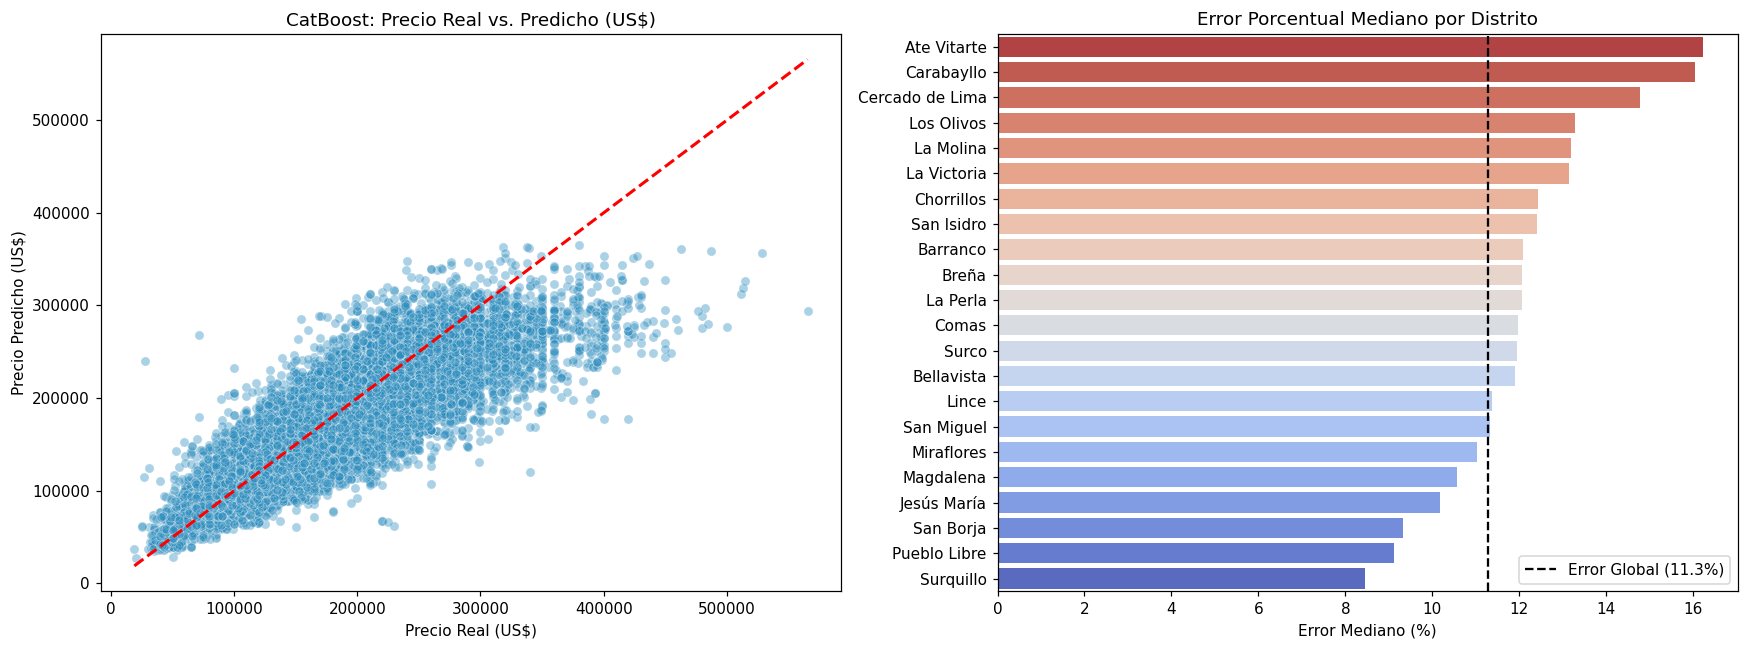

In [10]:
# 1. Preparar el DataFrame de diagnóstico con los resultados de CatBoost
df_diag = X_test.copy()
df_diag["Precio_Real"] = y_test
df_diag["Precio_Predicho"] = predicciones_ml["CatBoost"]
df_diag["Error_Pct"] = (abs(df_diag["Precio_Real"] - df_diag["Precio_Predicho"]) / df_diag["Precio_Real"]) * 100

# 2. Configurar el lienzo de matplotlib para gráficos duales
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Gráfico A: Dispersión Predicho vs Real ---
sns.scatterplot(
    data=df_diag, 
    x="Precio_Real", 
    y="Precio_Predicho", 
    alpha=0.4, 
    color="#2b8cbe",
    ax=axes[0]
)
# Línea de identidad (Predicción perfecta)
vmin = df_diag["Precio_Real"].min()
vmax = df_diag["Precio_Real"].max()
axes[0].plot([vmin, vmax], [vmin, vmax], color='red', linestyle='--', linewidth=2)

axes[0].set_title("CatBoost: Precio Real vs. Predicho (US$)")
axes[0].set_xlabel("Precio Real (US$)")
axes[0].set_ylabel("Precio Predicho (US$)")
axes[0].ticklabel_format(style='plain', axis='both') # Evitar notación científica

# --- Gráfico B: Error Mediano por Distrito ---
error_distrito = df_diag.groupby("distrito")["Error_Pct"].median().sort_values(ascending=False)

sns.barplot(
    x=error_distrito.values, 
    y=error_distrito.index, 
    hue=error_distrito.index,
    palette="coolwarm_r", 
    legend=False,
    ax=axes[1]
)
# Línea de referencia del error global
error_global = df_diag["Error_Pct"].median()
axes[1].axvline(error_global, color='black', linestyle='--', label=f'Error Global ({error_global:.1f}%)')

axes[1].set_title("Error Porcentual Mediano por Distrito")
axes[1].set_xlabel("Error Mediano (%)")
axes[1].set_ylabel("")
axes[1].legend()

plt.tight_layout()
plt.show()

### 6.1 Análisis de Residuales: Limitaciones y Propuestas de Mejora

A pesar de haber logrado un error global mediano sobresaliente del 11.3% con CatBoost, el análisis visual de los residuales revela dos limitaciones estructurales inherentes al uso exclusivo de datos tabulares. Para llevar el sistema a un entorno de producción a gran escala, se proponen las siguientes medidas correctoras para fases posteriores:

**1. Subestimación en el Segmento de Lujo (Techo Predictivo)**
* **Diagnóstico:** El gráfico de dispersión demuestra una alta precisión en propiedades estándar (hasta US$ 250,000). Sin embargo, a partir de los US$ 300,000, el modelo subestima sistemáticamente el valor real, aplanando la curva de predicción.
* **Causa Raíz:** En el mercado de ultralujo, el precio está dictado por variables cualitativas ausentes en este dataset (calidad de acabados, diseño arquitectónico de autor, vistas panorámicas).
* **Medida Correctora (Trabajo Futuro):** Integrar Procesamiento de Lenguaje Natural (NLP) para extraer atributos premium de la descripción del anuncio (ej. "mármol", "frente al mar", "domótica") y modelos de Visión Artificial para evaluar el estado de conservación a partir de fotografías.

**2. Sesgo Geográfico y Desbalance de Clases**
* **Diagnóstico:** El modelo rinde de forma excelente en "Lima Top" y Lima Moderna, pero los errores se disparan en distritos periféricos (ej. San Martín de Porres presenta un error mediano superior al 100%).
* **Causa Raíz:** Existe un severo desbalance de clases geográfico. La abrumadora mayoría de registros históricos se concentra en distritos de altos ingresos, dejando al algoritmo "ciego" ante la dinámica de precios en Lima Norte y Este. Además, la escasez de datos en estas zonas amplifica el impacto negativo de los errores de publicación (ej. terrenos publicados erróneamente como departamentos).
* **Medida Correctora (Trabajo Futuro):** Ejecutar una recolección de datos estratificada enfocada en la periferia, aplicar técnicas de sobremuestreo (oversampling) para balancear el peso espacial durante el entrenamiento, y diseñar filtros de calidad específicos por macrozona.

# Conclusiones finales

1. **El objetivo del proyecto se aborda mediante una estimación del precio de oferta.** Los datos de anuncios permiten modelar el precio pedido en dólares de departamentos en Lima Metropolitana. Las predicciones representan una referencia de oferta; el dataset no permite comprobar el precio final de compraventa.

2. **La exploración muestra un mercado heterogeneo.** La superficie, la dotación de ambientes y garajes, la antigüedad y el distrito presentan relaciones con el precio. Las diferencias entre distritos y la asimetría de los precios justifican considerar la ubicación y utilizar una transformación logarítmica de la variable objetivo. Estas asociaciones no demuestran por sí solas relaciones causales.

3. **La calidad y la cobertura temporal condicionan el alcance del modelo.** Se eliminaron 2,730 anuncios duplicados, se corrigieron inconsistencias y se descartaron columnas con fuga de información, redundantes o discontinuadas. Aunque el EDA estudió el segmento desde 2014, el modelado final utilizó el periodo **2022-2026**, con **40,368 registros y 26 distritos**, buscando una muestra más reciente y una cobertura geográfica más amplia.

4. **La evaluación temporal permite medir el desempeño sobre anuncios posteriores al entrenamiento.** Tras el filtro de extremos por distrito, ajustado únicamente con entrenamiento, se utilizaron **15,158 anuncios de 2022-2023** para entrenar y **25,048 de 2024-2026** para evaluar. Las métricas obtenidas corresponden a esta muestra filtrada; conviene evaluar también los anuncios excluidos para conocer el desempeño sobre toda la oferta.

5. **CatBoost obtuvo el mejor resultado entre los modelos comparados.** Según los resultados reportados, alcanzó un **error porcentual mediano de 11.3%**, frente al **14.9%** de la regla de mercado basada en distrito y superficie: una mejora de **3.6 puntos porcentuales**. El **45.3%** de las predicciones tuvo un error de hasta el 10%, y el RMSE disminuyó de **US$ 38,350** a **US$ 32,685**. Ridge también superó la referencia con un error mediano de **12.3%**, mientras que ElasticNet, con **19.4%**, no la superó en la configuraci?n evaluada.

6. **El resultado global no implica la misma precisión en todos los segmentos.** El diagnóstico reportado identifica subestimación en inmuebles de alto precio y errores elevados en algunos distritos periféricos. La ausencia de atributos como acabados, estado de conservación y ubicación precisa, junto con diferencias en la cantidad y calidad de anuncios por distrito, limita la valoración. Por ello, el modelo puede apoyar una estimación inicial, pero requiere revisión específica en los segmentos con mayor error.

7. **Las siguientes mejoras deben centrarse en la representatividad y la validación.** Se recomienda ampliar y revisar los datos de distritos con menor cobertura, incorporar atributos de los anuncios y evaluar el error por distrito y rango de precio junto con su número de observaciones. También queda pendiente resolver los **4 duplicados residuales** detectados tras la preparación, comprobar posibles anuncios repetidos entre entrenamiento y prueba y validar en nuevos periodos. La selección de hiperparámetros debe realizarse con particiones temporales dentro del entrenamiento, reservando una muestra posterior para la evaluación final.

**Conclusión general.** Los resultados respaldan el uso de modelos supervisados como apoyo para estimar precios de oferta en el mercado observado. CatBoost mejora la referencia de mercado en la evaluación realizada, pero su utilidad depende de la calidad de los datos, el segmento del inmueble y la estabilidad de su desempeño en periodos posteriores.